<a href="https://colab.research.google.com/github/CatGelvez01/Ciencia_de_datos_aplicada_taller-1/blob/main/Intouch_Data_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA ASSESMENT - ANA C. GELVEZ

# Nueva sección

In [1]:
#Libreriras básicas
import re
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#Intalación librerias extras
%pip install levenshtein
%pip install seaborn
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.2 MB/s eta 0:00:00


In [3]:
#Importación seaborn y scipy para visualización
import seaborn as sns
from scipy.stats import ttest_ind, shapiro, mannwhitneyu, chi2_contingency

from Levenshtein import distance, ratio

In [4]:
pd.set_option("display.max_columns", None)

## **1. Review the datasets and their attributes.**
### Data Governance
1.1) Data Quality
* Accuracy
* Completeness
* Reliability
* Timeliness


**CSAT DATA SET**

In [5]:
#Dataset importado correctamente - csat_data.cvs

csat_df=pd.read_csv('/content/drive/MyDrive/DataIntouch/csat_data.csv')
csat_df.head()

,week,response_date,contact_method,csat_count,sat_time,professionalism,knowledge,clarity,understand_needs,ability_solve,empathy,inquiry_resolved,inquiry_contact_count,topic_1_2_3,Tenure_Bucket,agent_name
0,2024-07-28,2024-07-31,Email,0,1,0,0,0,0,0,0,No,2-3 Times,Salon | Services Issue | Hair Service,Days 180+,Agent_2
1,2024-04-07,2024-04-10,Email,0,0,0,0,0,0,0,0,No,2-3 Times,Store | Guest Service Issues | Associate Issue,Days 180+,Agent_2
2,2024-04-28,2024-04-28,Email,0,0,0,0,0,0,0,0,No,First Contact,Store | Guest Service Issues | Associate Issue,Days 180+,Agent_2
3,2024-06-09,2024-06-09,Voice,0,0,0,0,0,0,0,1,No,2-3 Times,Store | Returns and Refunds | Return Policy Co...,Days 180+,Agent_2
4,2024-05-05,2024-05-05,Email,0,0,0,0,0,0,0,0,No,First Contact,Salon | Services Issue | Hair Service,Days 180+,Agent_2


In [6]:
#CSAT DATASET
#Tipo de dato, nombre columna, número filas, datos y espacios en null

csat_df.dtypes
csat_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   week                   4395 non-null   object
 1   response_date          4395 non-null   object
 2   contact_method         4395 non-null   object
 3   csat_count             4395 non-null   int64 
 4   sat_time               4395 non-null   int64 
 5   professionalism        4395 non-null   int64 
 6   knowledge              4395 non-null   int64 
 7   clarity                4395 non-null   int64 
 8   understand_needs       4395 non-null   int64 
 9   ability_solve          4395 non-null   int64 
 10  empathy                4395 non-null   int64 
 11  inquiry_resolved       4349 non-null   object
 12  inquiry_contact_count  4361 non-null   object
 13  topic_1_2_3            4395 non-null   object
 14  Tenure_Bucket          4395 non-null   object
 15  agent_name           

In [7]:

csat_df.describe()

,csat_count,sat_time,professionalism,knowledge,clarity,understand_needs,ability_solve,empathy
count,4395.000000,4395.000000,4395.0,4395.0,4395.000000,4395.0,4395.000000,4395.000000
mean,0.679863,0.696701,0.0,0.0,0.753356,0.0,0.696018,0.768373
std,0.466582,0.459736,0.0,0.0,0.431107,0.0,0.460027,0.421920
min,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.0,0.0,1.000000,0.0,0.000000,1.000000
50%,1.000000,1.000000,0.0,0.0,1.000000,0.0,1.000000,1.000000
75%,1.000000,1.000000,0.0,0.0,1.000000,0.0,1.000000,1.000000
max,1.000000,1.000000,0.0,0.0,1.000000,0.0,1.000000,1.000000


In [8]:
#CSAT DATASET
#Tipo de atributos - Categoricos (nominales o ordinales) o Cuantitativas (Variables discretas o continuas)


#Número de final según tipo de dato
num_object = len(csat_df.select_dtypes(include=['object']).columns)
num_int    = len(csat_df.select_dtypes(include=['int']).columns)

print("Object columns:", num_object)
print("Integer columns:", num_int)


Object columns: 8
Integer columns: 8


In [9]:
csat_df.shape

(4395, 16)

In [10]:
#Revisión de espacios vacios o en null
csat_df.isnull().sum()

,0
week,0
response_date,0
contact_method,0
csat_count,0
sat_time,0
professionalism,0
knowledge,0
clarity,0
understand_needs,0
ability_solve,0


In [11]:
#Porcentaje de espacios vacios o nulls en el dataset
csat_df.isnull().mean() * 100


,0
week,0.000000
response_date,0.000000
contact_method,0.000000
csat_count,0.000000
sat_time,0.000000
professionalism,0.000000
knowledge,0.000000
clarity,0.000000
understand_needs,0.000000
ability_solve,0.000000


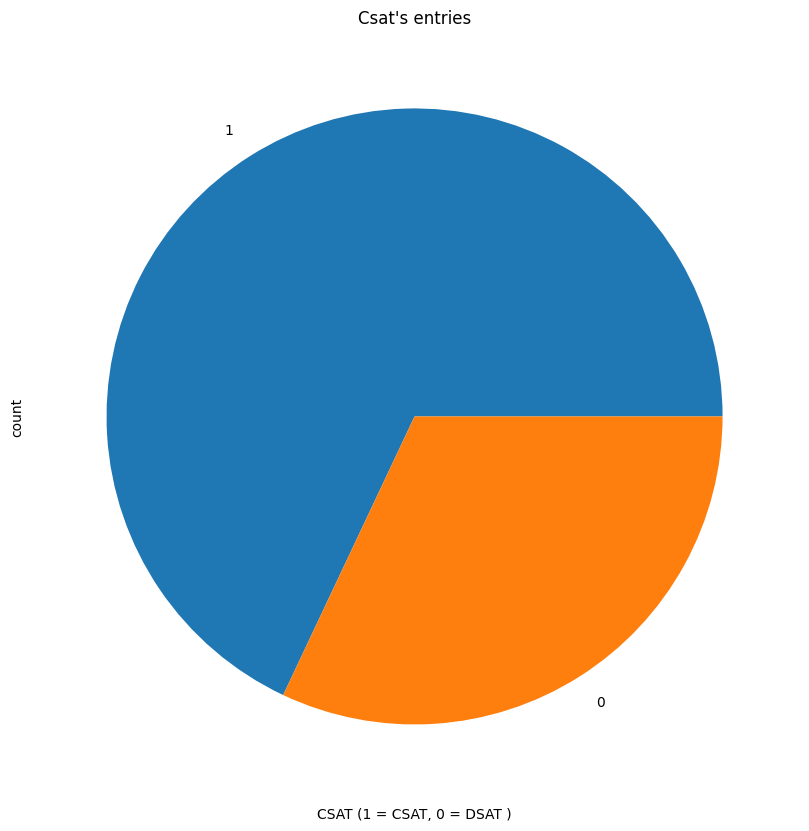

In [12]:
plt.figure(figsize=(10,10))
grafs = csat_df['csat_count'].value_counts().plot(kind='pie', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("Csat's entries")
plt.xlabel("CSAT (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

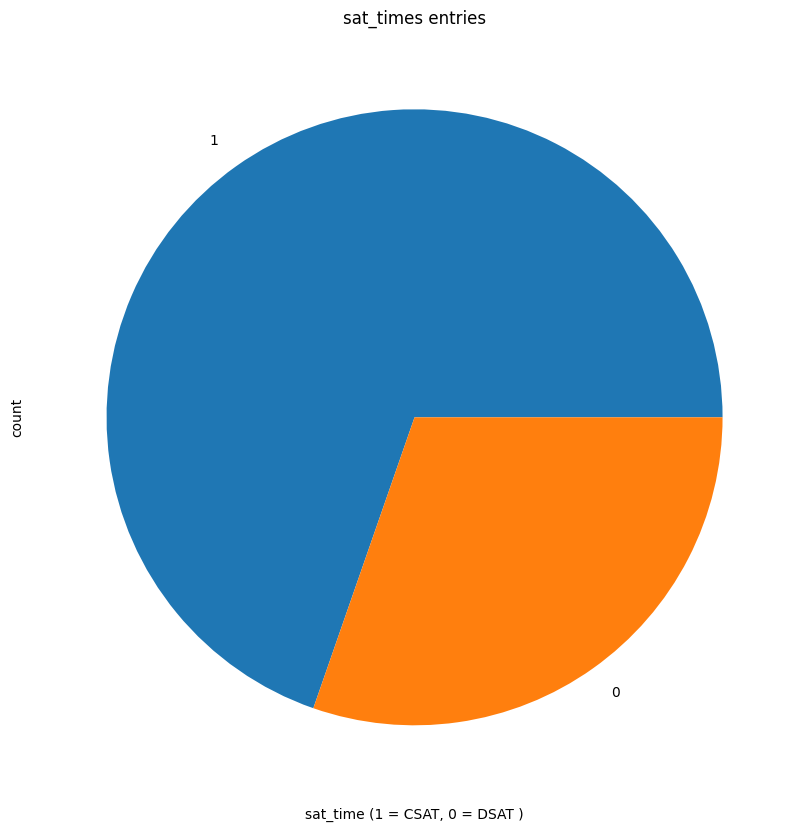

In [13]:
plt.figure(figsize=(10,10))
grafs = csat_df['sat_time'].value_counts().plot(kind='pie', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("sat_times entries")
plt.xlabel("sat_time (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

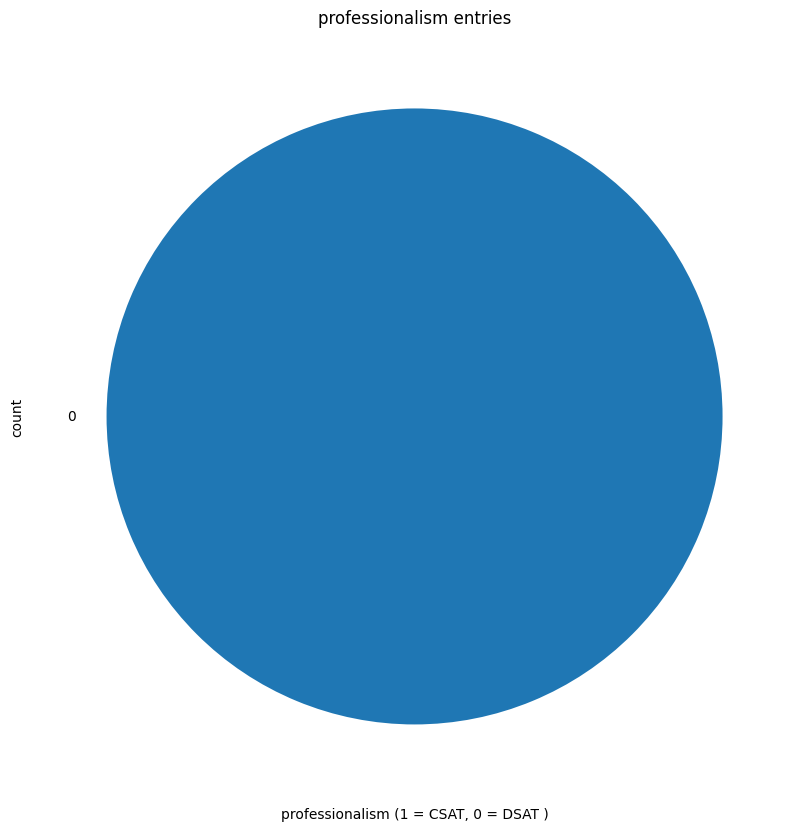

In [14]:
plt.figure(figsize=(10,10))
grafs = csat_df['professionalism'].value_counts().plot(kind='pie', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("professionalism entries")
plt.xlabel("professionalism (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

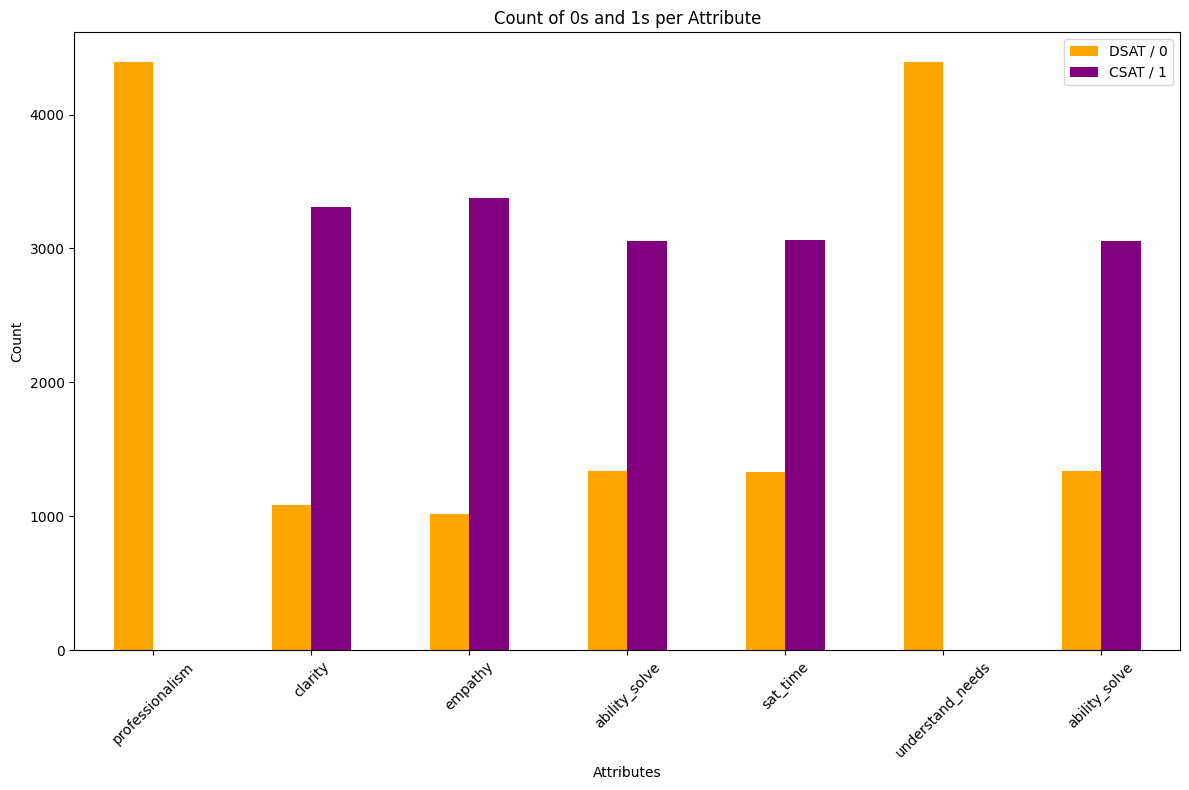

In [15]:
import matplotlib.pyplot as plt

# Select the binary columns you want to visualize
columns_to_plot = ['professionalism', 'clarity', 'empathy', 'ability_solve', 'sat_time', 'understand_needs', 'ability_solve']

# Count values for each column (1s and 0s)
value_counts_df = csat_df[columns_to_plot].apply(lambda x: x.value_counts()).fillna(0)

# Transpose so we can plot categories as bars
value_counts_df = value_counts_df.T  # Now rows = attributes, columns = [0, 1]

# Plot
value_counts_df.plot(kind='bar', figsize=(12, 8), color=['orange', 'purple'])

plt.title("Count of 0s and 1s per Attribute")
plt.xlabel("Attributes")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["DSAT / 0", "CSAT / 1"])
plt.tight_layout()
plt.show()

In [16]:
#Valores en en el atributo Agent_name
csat_df['agent_name'].unique().tolist()

['Agent_2',
 'Agent_39',
 'Agent_23',
 'Agent_29',
 'Agent_40',
 'Agent_15',
 'Agent_41',
 'Agent_42',
 'Agent_6',
 'Agent_43',
 'Agent_11',
 'Agent_4',
 'Agent_34',
 'Agent_44',
 'Agent_45',
 'Agent_3',
 'Agent_46',
 'Agent_47',
 'Agent_48',
 'Agent_49',
 'Agent_20',
 'Agent_50',
 'Agent_17',
 'Agent_51',
 'Agent_8',
 'Agent_52',
 'Agent_53',
 'Agent_21',
 'Agent_12',
 'Agent_54',
 'Agent_55',
 'Agent_24',
 'Agent_56',
 'Agent_13',
 'Agent_57',
 'Agent_58',
 'Agent_59',
 'Agent_22',
 'Agent_60',
 'Agent_19',
 'Agent_61',
 'Agent_26',
 'Agent_62',
 'Agent_30',
 'Agent_35',
 'Agent_1',
 'Agent_63',
 'Agent_64',
 'Agent_65',
 'Agent_66',
 'Agent_67',
 'Agent_68',
 'Agent_69',
 'Agent_70',
 'Agent_71',
 'Agent_16',
 'Agent_9',
 'Agent_72',
 'Agent_73',
 'Agent_7',
 'Agent_74',
 'Agent_75',
 'Agent_10',
 'Agent_76',
 'Agent_77',
 'Agent_78',
 'Agent_14',
 'Agent_79',
 'Agent_25',
 'Agent_5',
 'Agent_32',
 'Agent_31',
 'Agent_80',
 'Agent_81',
 'Agent_82',
 'Agent_83',
 'Agent_84',
 'Agent_

In [17]:
#Atributo Agent_Name
pd.set_option('display.max_rows', None)  # Removes row limit for display
print(csat_df["agent_name"].value_counts())

agent_name
Agent_19    271
Agent_3     244
Agent_16    217
Agent_7     204
Agent_17    184
Agent_14    178
Agent_48    157
Agent_50    155
Agent_4     155
Agent_2     155
Agent_47    154
Agent_1     153
Agent_10    135
Agent_15    129
Agent_5     118
Agent_41    114
Agent_43    109
Agent_9     101
Agent_8      88
Agent_23     83
Agent_64     82
Agent_12     72
Agent_26     71
Agent_11     52
Agent_31     48
Agent_18     47
Agent_30     47
Agent_13     45
Agent_53     45
Agent_70     43
Agent_85     42
Agent_24     38
Agent_61     38
Agent_79     34
Agent_44     30
Agent_32     28
Agent_21     28
Agent_46     27
Agent_62     26
Agent_34     24
Agent_51     24
Agent_65     23
Agent_35     23
Agent_55     23
Agent_20     23
Agent_83     22
Agent_81     21
Agent_29     21
Agent_25     19
Agent_77     19
Agent_33     18
Agent_84     14
Agent_89     13
Agent_88     12
Agent_49     11
Agent_58     11
Agent_72     10
Agent_45     10
Agent_69      9
Agent_63      9
Agent_68      8
Agent_87     

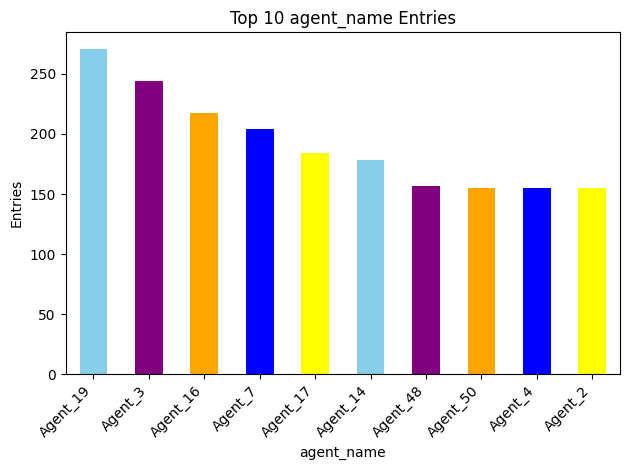

In [18]:
# Get top 10 topics
top_topics = csat_df['agent_name'].value_counts().head(10)

# Plot
top_topics.plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("Top 10 agent_name Entries")
plt.ylabel("Entries")
plt.xlabel("agent_name")
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

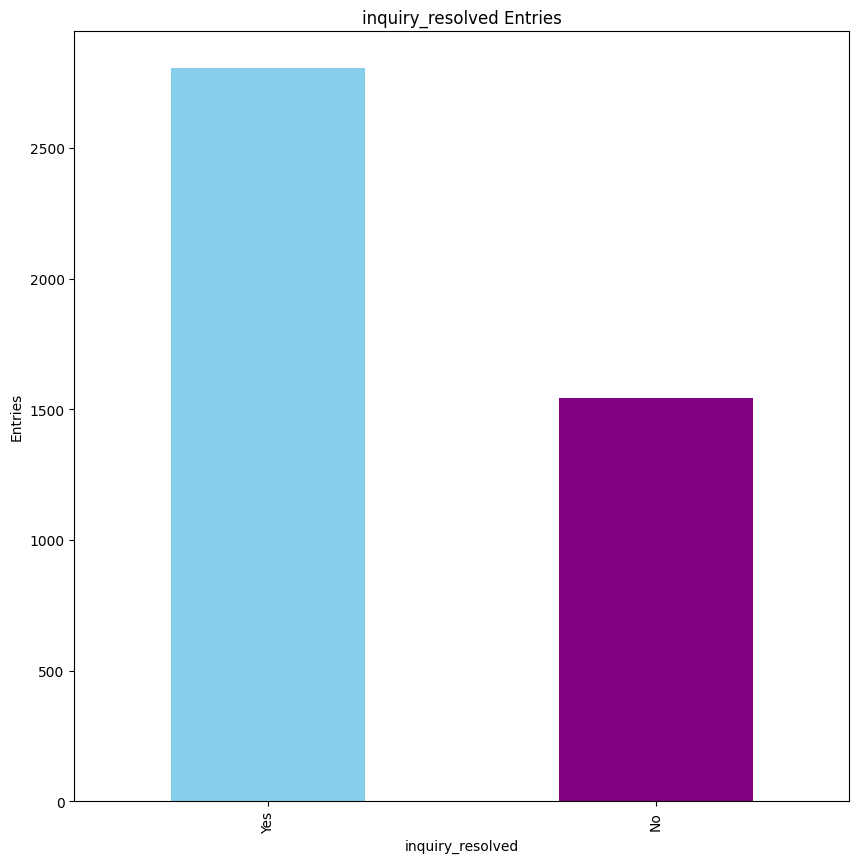

In [19]:
plt.figure(figsize=(10,10))
grafs = csat_df['inquiry_resolved'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("inquiry_resolved Entries")
plt.ylabel("Entries")
plt.xlabel("inquiry_resolved")
plt.tick_params(axis='x', labelsize=10)

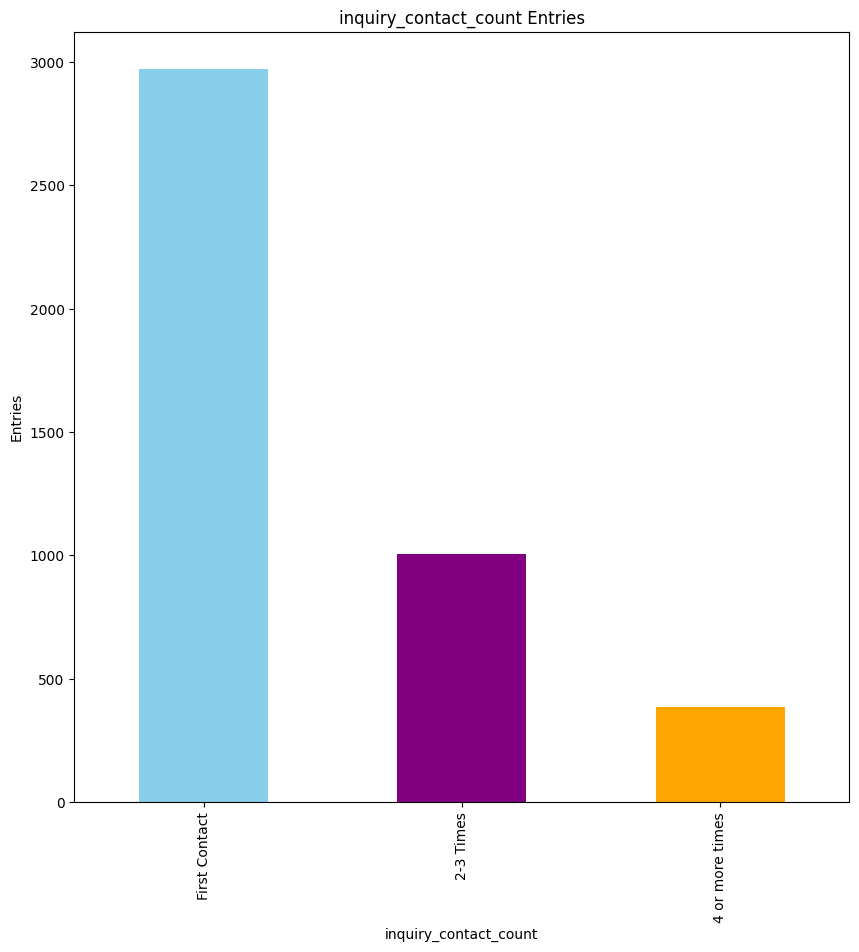

In [20]:


plt.figure(figsize=(10,10))
grafs = csat_df['inquiry_contact_count'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("inquiry_contact_count Entries")
plt.ylabel("Entries")
plt.xlabel("inquiry_contact_count")
plt.tick_params(axis='x', labelsize=10)

In [21]:
csat_df['topic_1_2_3'].unique().tolist()

['Salon | Services Issue | Hair Service',
 'Store | Guest Service Issues | Associate Issue',
 'Store | Returns and Refunds | Return Policy Complaint',
 'Rewards Program | Update Account | Merge/Multiple Accounts',
 'Store | Product Information | Out of Stock Issues',
 'Store | Compliment | Store',
 'Salon | Appointment Issue | Associate Issue',
 'Website | Product Information | Out of Stock',
 'Rewards Program | Gift Cards | Funds Removed',
 'Website | Coupon/Special Offers | GWP OOS',
 'Website | Shipment Issue | Delivery Status',
 'Website | Web Order Returns and Refunds | Procedure Question',
 'Rewards Program | Update Account | Update Address/Email/Phone Number',
 'Salon | Services Issue | Benefit Brow Service',
 'Store | Guest Service Issues | Store Policies and Procedures',
 'Website | Shipment Issue | Damaged Item',
 'Store | Product Information | Current Product',
 'Store | Returns and Refunds | Missing Refund',
 'Salon | Services Issue | Pricing Issue',
 'Salon | Appointment I

In [22]:

print(csat_df["topic_1_2_3"].value_counts())

topic_1_2_3
Store | Guest Service Issues | Associate Issue                                          327
Rewards Program | Program Questions | Birthday Coupon                                   167
Website | Shipment Issue | Missing Item                                                 164
Salon | Services Issue | Hair Service                                                   159
Website | Shipment Issue | Delivery Status                                              157
Website | Shipment Issue | Damaged Item                                                 141
Website | Coupon/Special Offers Issue | Coupon Did Not Apply                            135
Rewards Program | Points Issue | Didn't Receive Points for Order                        130
Website | Account Issue | Can't Access Account                                          113
Website | Shipment Issue | Delivered Not Received                                       108
Store | Compliment | Store                                          

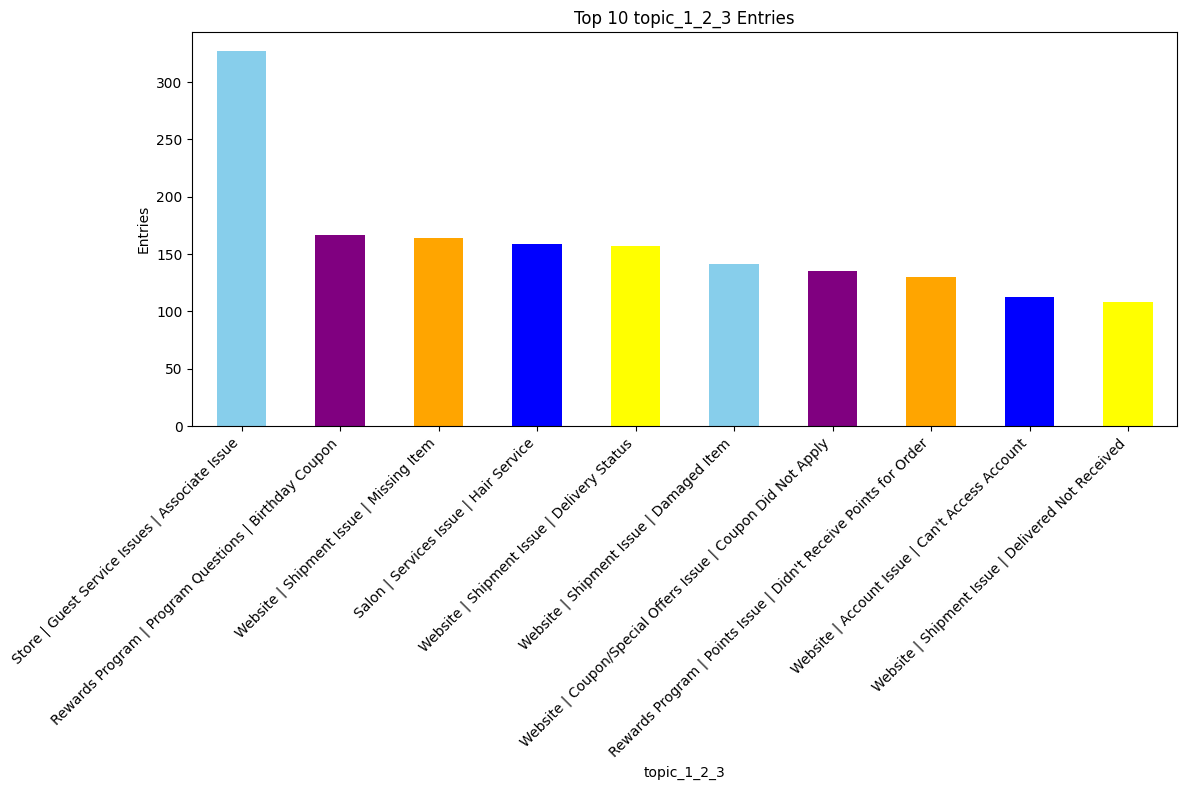

In [23]:

plt.figure(figsize=(12, 8))

# Get top 10 topics
top_topics = csat_df['topic_1_2_3'].value_counts().head(10)

# Plot
top_topics.plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("Top 10 topic_1_2_3 Entries")
plt.ylabel("Entries")
plt.xlabel("topic_1_2_3")
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

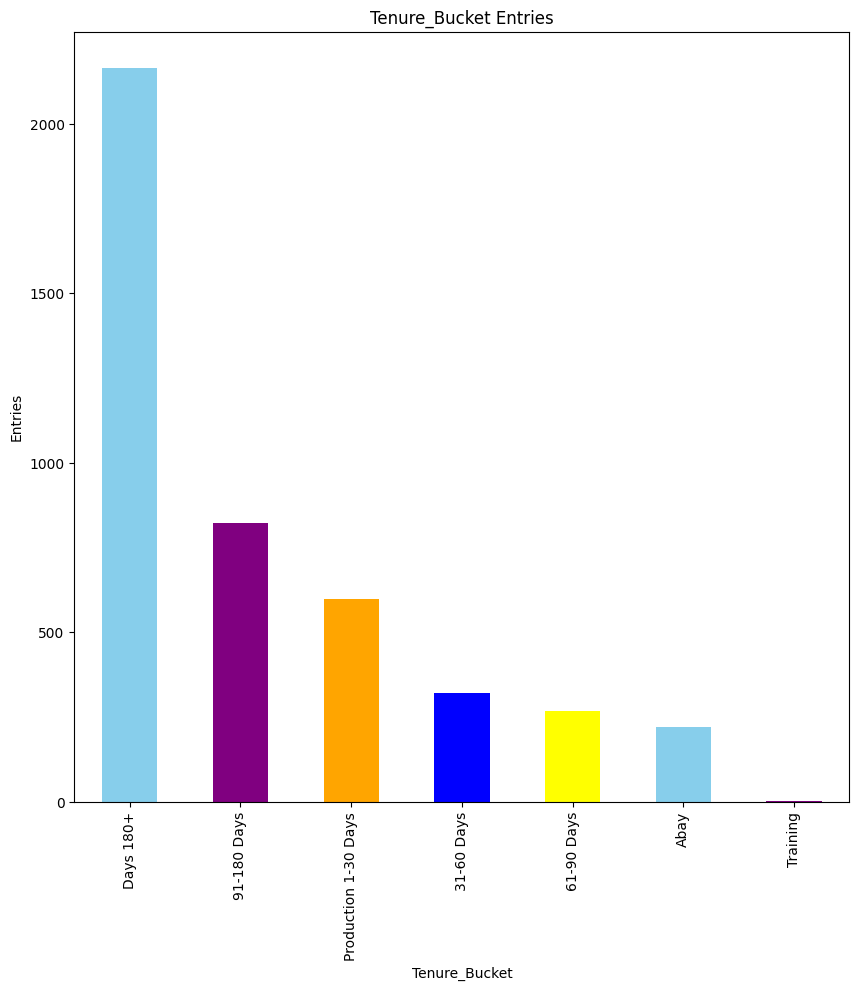

In [24]:

plt.figure(figsize=(10,10))
grafs = csat_df['Tenure_Bucket'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("Tenure_Bucket Entries")
plt.ylabel("Entries")
plt.xlabel("Tenure_Bucket")
plt.tick_params(axis='x', labelsize=10)

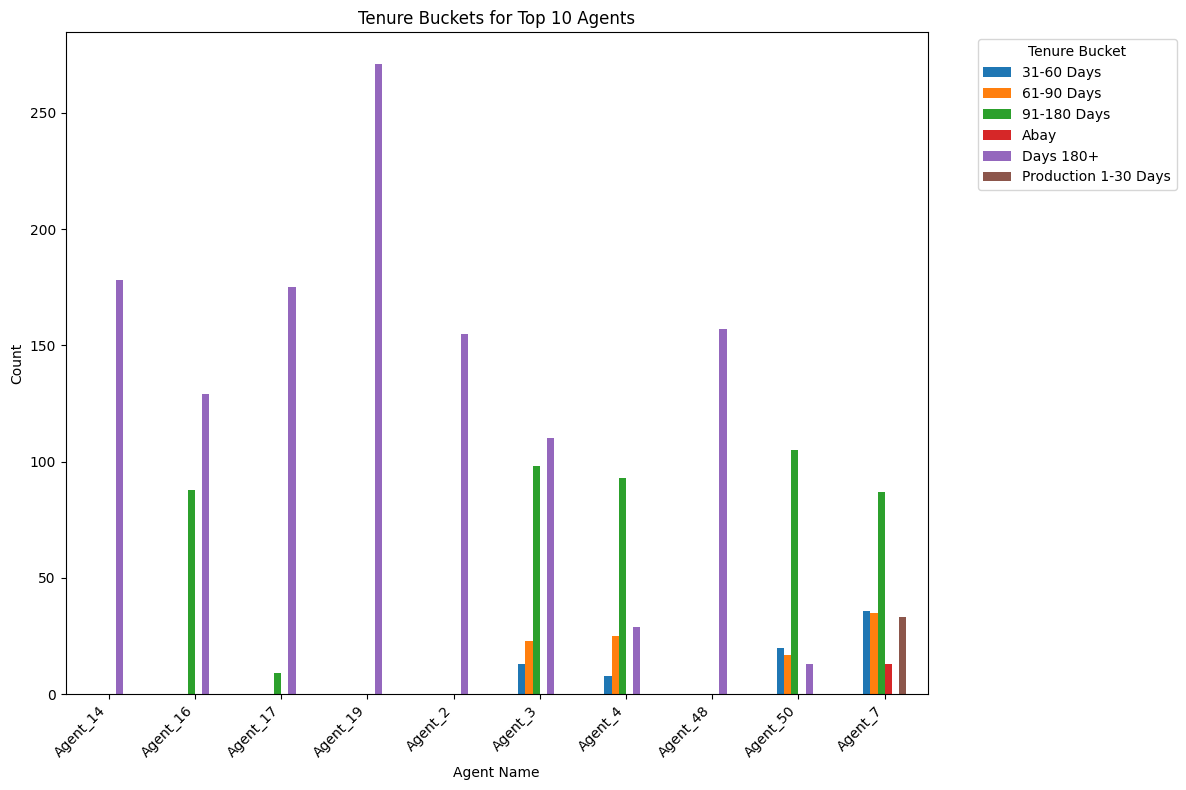

In [25]:
top_agents = csat_df["agent_name"].value_counts().head(10).index.tolist()

# Step 2: Filter to only those top 10 agents
top_agents_data = csat_df[csat_df["agent_name"].isin(top_agents)]

# Step 3: Create a crosstab of agent_name vs Tenure_Bucket
agent_tenure_counts = pd.crosstab(top_agents_data["agent_name"], top_agents_data["Tenure_Bucket"])

# Step 4: Plot the grouped bar chart
agent_tenure_counts.plot(kind='bar', figsize=(12, 8))

plt.title("Tenure Buckets for Top 10 Agents")
plt.xlabel("Agent Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Tenure Bucket", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

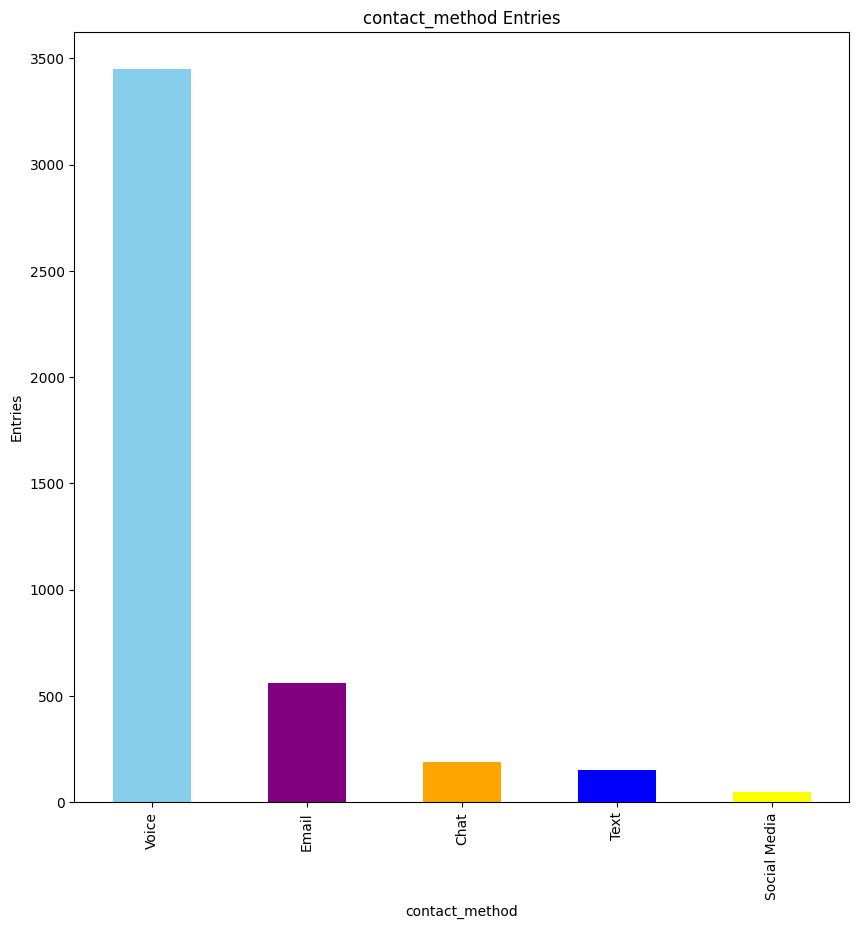

In [26]:

plt.figure(figsize=(10,10))
grafs = csat_df['contact_method'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("contact_method Entries")
plt.ylabel("Entries")
plt.xlabel("contact_method")
plt.tick_params(axis='x', labelsize=10)

AUDIT DATA SET

In [27]:
#Dataset importado correctamente - self_audit_data.cvs

audit_df = pd.read_csv('/content/drive/MyDrive/DataIntouch/self_audit_data.csv')
audit_df.head()

,date,agent_name,team_leader,home_channel,topic_1_2_3,professionalism,clarity,empathy,value_guest_time,ability_solve,opportunities,further_support,csat_count,self_csat
0,2024-03-30,Agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1
1,2024-03-30,Agent_2,Team_Leader_36,Store Team,Store - Guest Service Issues - Associate Issue,1,1,1,1,1,Resource Utilization,Customer Satisfaction,1,1
2,2024-03-29,Agent_3,Team_Leader_37,Voice,Website - Shipment Issue - Delivery Status,1,0,0,0,1,Effective Communication,Customer Satisfaction,0,1
3,2024-03-28,Agent_4,Team_Leader_37,Voice,Website - Shipment Issue - Stuck in Status,1,1,1,1,0,Professionalism,De-Escalation,0,0
4,2024-04-05,Agent_5,Team_Leader_36,Store Team,Salon - Services Issue - Facilities Issue,1,1,1,1,1,Effective Communication,Customer Satisfaction,1,1


In [28]:
#AUDIT DATASET
#Tipo de dato, nombre columna, número filas, datos y espacios en null

audit_df.dtypes
audit_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              117 non-null    object
 1   agent_name        117 non-null    object
 2   team_leader       117 non-null    object
 3   home_channel      117 non-null    object
 4   topic_1_2_3       117 non-null    object
 5   professionalism   117 non-null    int64 
 6   clarity           117 non-null    int64 
 7   empathy           117 non-null    int64 
 8   value_guest_time  117 non-null    int64 
 9   ability_solve     117 non-null    int64 
 10  opportunities     117 non-null    object
 11  further_support   117 non-null    object
 12  csat_count        117 non-null    int64 
 13  self_csat         117 non-null    int64 
dtypes: int64(7), object(7)
memory usage: 12.9+ KB


In [29]:
#AUDIT DATASET
#Tipo de atributos - Categoricos (nominales o ordinales) o Cuantitativas (Variables discretas o continuas)


#Número de final según tipo de dato
num_object = len(audit_df.select_dtypes(include=['object']).columns)
num_int    = len(audit_df.select_dtypes(include=['int']).columns)

print("Object columns:", num_object)
print("Integer columns:", num_int)

Object columns: 7
Integer columns: 7


In [30]:
audit_df.describe()

,professionalism,clarity,empathy,value_guest_time,ability_solve,csat_count,self_csat
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,0.957265,0.923077,0.803419,0.880342,0.769231,0.316239,0.854701
std,0.203129,0.267615,0.399122,0.325957,0.423137,0.467008,0.353918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
#Revisión de espacios vacios o en null
audit_df.isnull().sum()

,0
date,0
agent_name,0
team_leader,0
home_channel,0
topic_1_2_3,0
professionalism,0
clarity,0
empathy,0
value_guest_time,0
ability_solve,0


In [32]:
#Porcentaje de espacios vacios o nulls en el dataset
audit_df.isnull().mean() * 100


,0
date,0.0
agent_name,0.0
team_leader,0.0
home_channel,0.0
topic_1_2_3,0.0
professionalism,0.0
clarity,0.0
empathy,0.0
value_guest_time,0.0
ability_solve,0.0


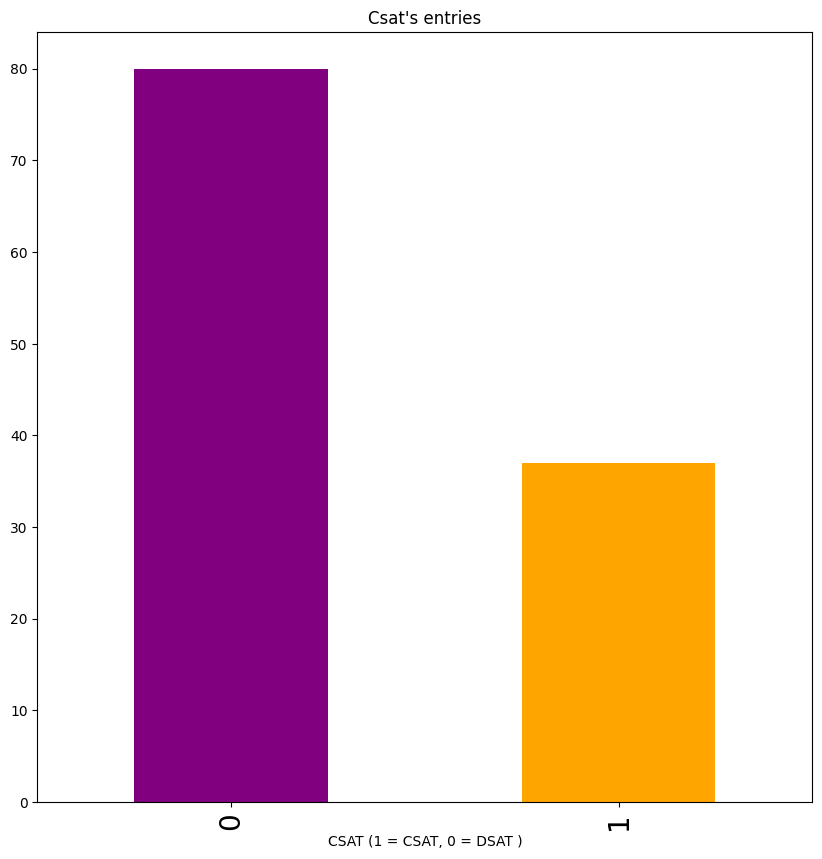

In [33]:
plt.figure(figsize=(10,10))
grafs = audit_df['csat_count'].value_counts().plot(kind='bar', color=[ 'purple', 'orange' ])

plt.title("Csat's entries")
plt.xlabel("CSAT (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

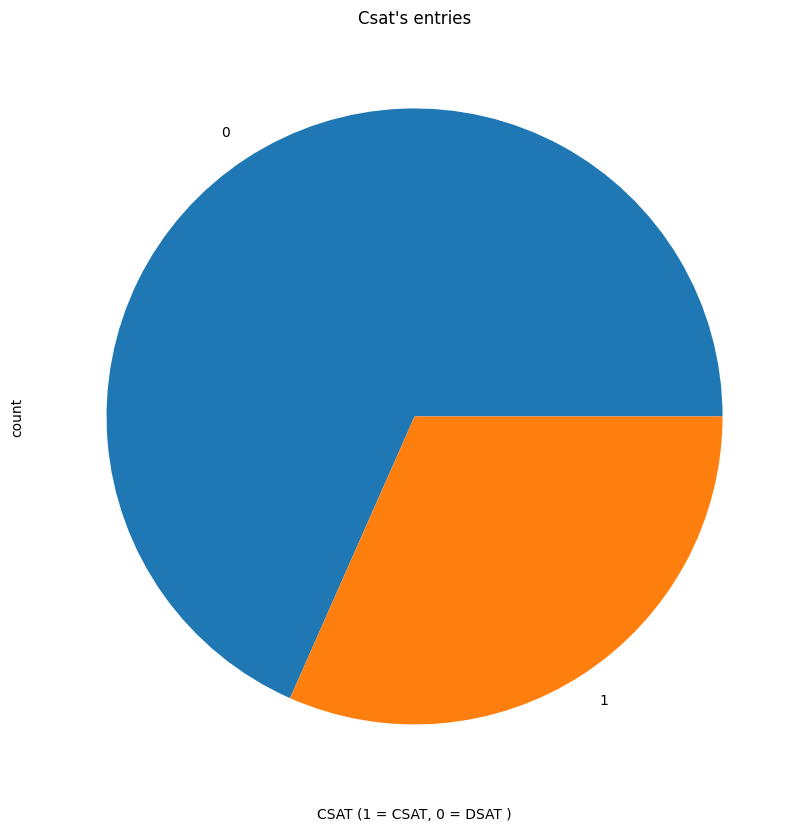

In [34]:
plt.figure(figsize=(10,10))
grafs = audit_df['csat_count'].value_counts().plot(kind='pie', color=[ 'purple', 'orange' ])

plt.title("Csat's entries")
plt.xlabel("CSAT (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

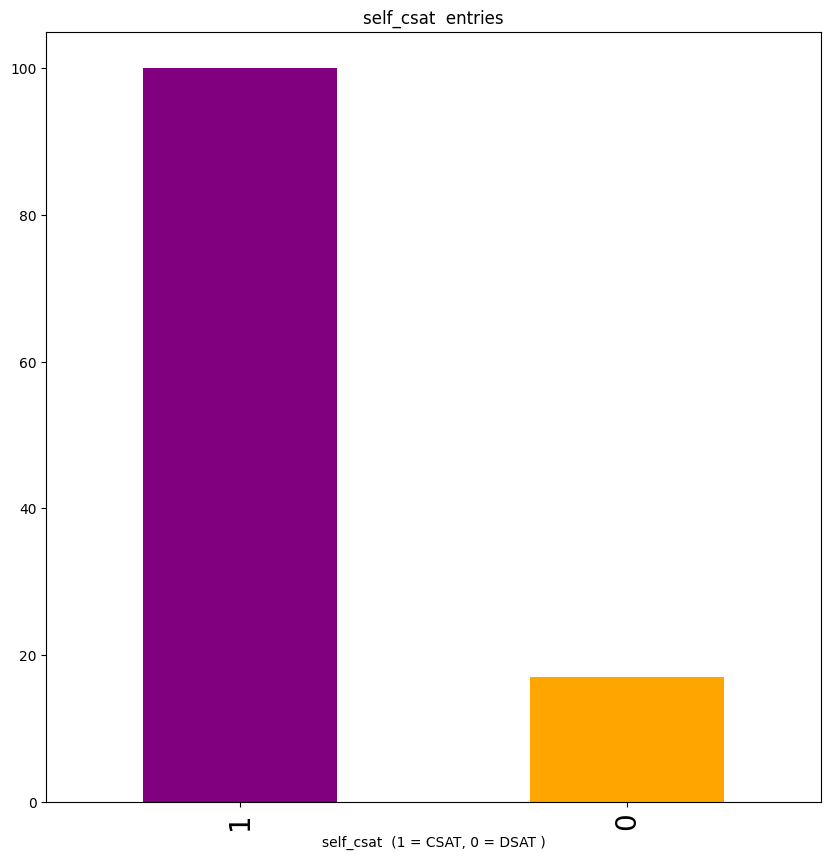

In [35]:
plt.figure(figsize=(10,10))
grafs = audit_df['self_csat'].value_counts().plot(kind='bar', color=[ 'purple', 'orange' ])

plt.title("self_csat  entries")
plt.xlabel("self_csat  (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

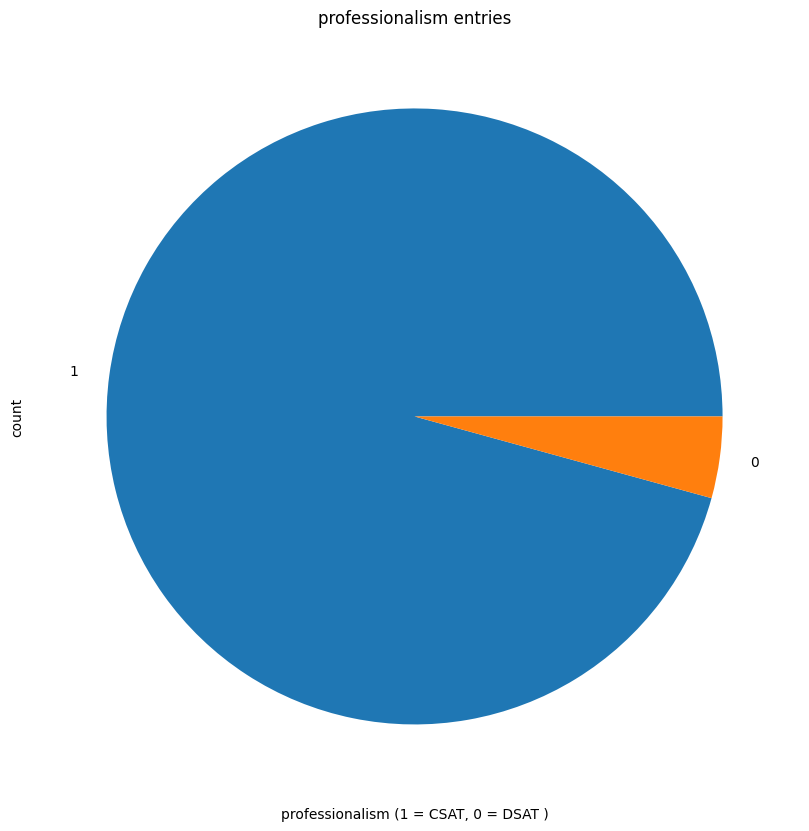

In [36]:

plt.figure(figsize=(10,10))
grafs = audit_df['professionalism'].value_counts().plot(kind='pie', color=[ 'purple', 'orange' ])

plt.title("professionalism entries")
plt.xlabel("professionalism (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

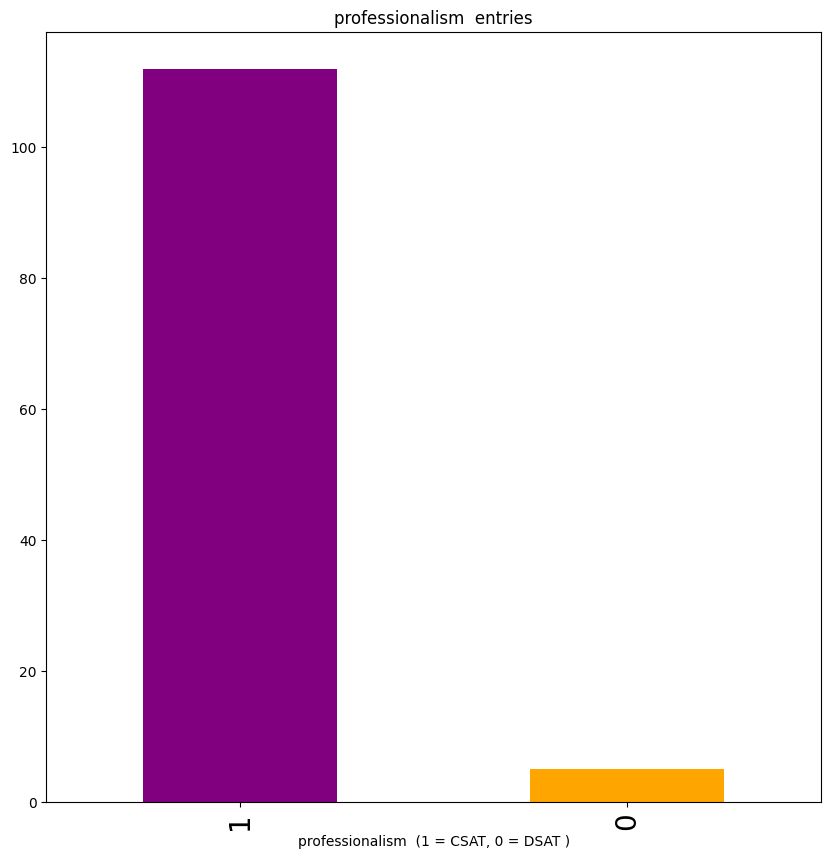

In [37]:
plt.figure(figsize=(10,10))
grafs = audit_df['professionalism'].value_counts().plot(kind='bar', color=[ 'purple', 'orange' ])

plt.title("professionalism  entries")
plt.xlabel("professionalism  (1 = CSAT, 0 = DSAT )")
plt.tick_params(axis='x', labelsize=20)

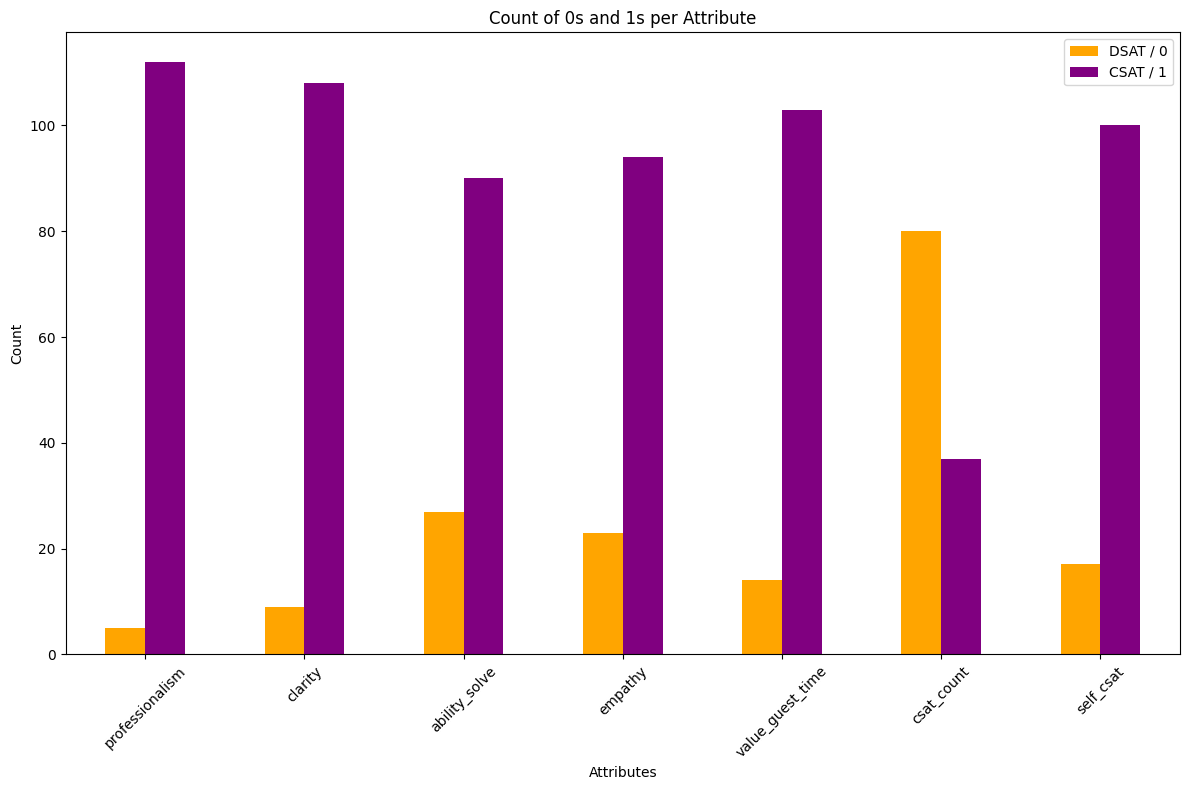

In [38]:
columns_to_plot = ['professionalism', 'clarity', 'ability_solve', 'empathy', 'value_guest_time', 'csat_count', 'self_csat']

# Count values for each column (1s and 0s)
value_counts_df = audit_df[columns_to_plot].apply(lambda x: x.value_counts()).fillna(0)

# Transpose so we can plot categories as bars
value_counts_df = value_counts_df.T  # Now rows = attributes, columns = [0, 1]

# Plot
value_counts_df.plot(kind='bar', figsize=(12, 8), color=['orange', 'purple'])

plt.title("Count of 0s and 1s per Attribute")
plt.xlabel("Attributes")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["DSAT / 0", "CSAT / 1"])
plt.tight_layout()
plt.show()

In [39]:
#Valores en en el atributo Agent_name
audit_df['agent_name'].unique().tolist()

['Agent_1',
 'Agent_2',
 'Agent_3',
 'Agent_4',
 'Agent_5',
 'Agent_6',
 'Agent_7',
 'Agent_8',
 'Agent_9',
 'Agent_10',
 'Agent_11',
 'Agent_12',
 'Agent_13',
 'Agent_14',
 'Agent_15',
 'Agent_16',
 'Agent_17',
 'Agent_18',
 'Agent_19',
 'Agent_20',
 'Agent_21',
 'Agent_22',
 'Agent_23',
 'Agent_24',
 'Agent_25',
 'Agent_26',
 'Agent_27',
 'Agent_28',
 'Agent_29',
 'Agent_30',
 'Agent_31',
 'Agent_32',
 'Agent_33',
 'Agent_34',
 'Agent_35']

In [40]:
pd.set_option('display.max_rows', None)
print(audit_df["agent_name"].value_counts())

agent_name
Agent_7     21
Agent_29    10
Agent_19     9
Agent_17     7
Agent_5      6
Agent_2      6
Agent_16     5
Agent_12     5
Agent_1      4
Agent_21     4
Agent_10     4
Agent_23     3
Agent_28     3
Agent_8      3
Agent_3      2
Agent_13     2
Agent_15     2
Agent_9      2
Agent_22     2
Agent_24     2
Agent_18     1
Agent_6      1
Agent_11     1
Agent_4      1
Agent_14     1
Agent_20     1
Agent_25     1
Agent_27     1
Agent_26     1
Agent_30     1
Agent_31     1
Agent_32     1
Agent_33     1
Agent_34     1
Agent_35     1
Name: count, dtype: int64


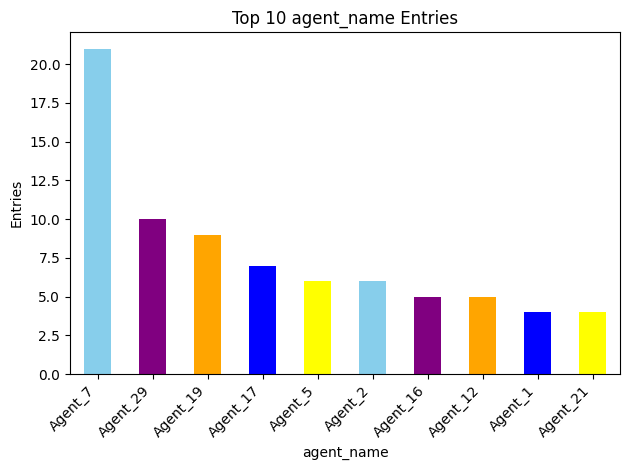

In [41]:
top_topics = audit_df['agent_name'].value_counts().head(10)

# Plot
top_topics.plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("Top 10 agent_name Entries")
plt.ylabel("Entries")
plt.xlabel("agent_name")
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

In [42]:
audit_df['team_leader'].unique().tolist()

['Team_Leader_36', 'Team_Leader_37', 'Team_Leader_38']

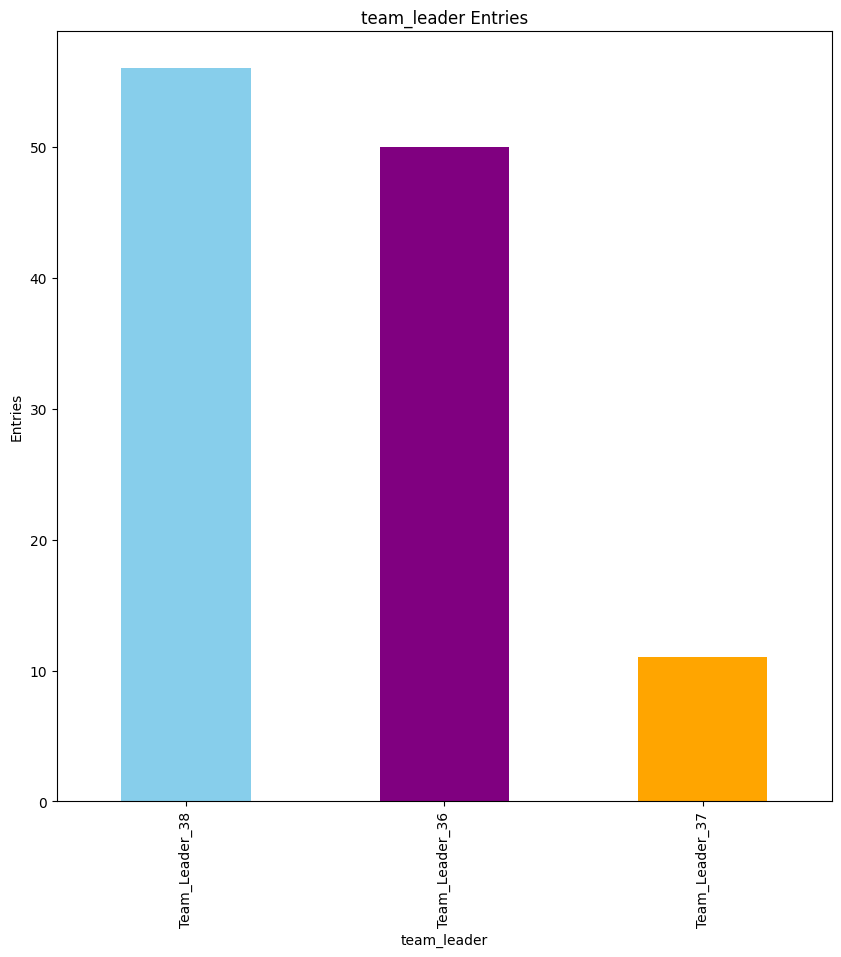

In [43]:
plt.figure(figsize=(10,10))
grafs = audit_df['team_leader'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("team_leader Entries")
plt.ylabel("Entries")
plt.xlabel("team_leader")
plt.tick_params(axis='x', labelsize=10)

In [44]:

audit_df['home_channel'].unique().tolist()

['Voice', 'Store Team', 'Email', 'CSR2', 'Other Support']

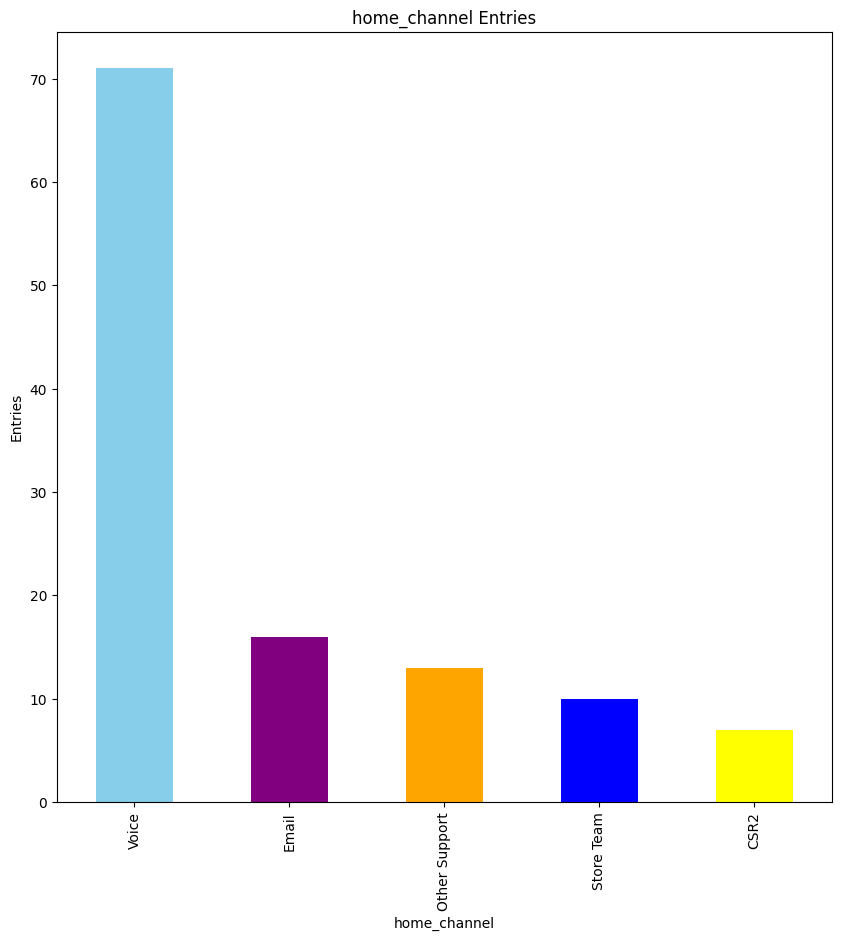

In [45]:
plt.figure(figsize=(10,10))
grafs = audit_df['home_channel'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("home_channel Entries")
plt.ylabel("Entries")
plt.xlabel("home_channel")
plt.tick_params(axis='x', labelsize=10)

In [46]:

audit_df['topic_1_2_3'].unique().tolist()

['Website - Shipment Issue - Delivery Status',
 'Store - Guest Service Issues - Associate Issue',
 'Website - Shipment Issue - Stuck in Status',
 'Salon - Services Issue - Facilities Issue',
 'Website - Buy Online Pickup in Store - Curbside Order Wait Time',
 'Rewards Program - Program Questions - Birthday Coupon',
 'Store - Guest Service Issues - Store Policies and Procedures',
 'Salon - Services Issue - Associate Issue',
 'Website - Buy Online Pickup in Store - Order Incorrectly Marked As Picked Up \u200b',
 'Website - Buy Online Pickup in Store - Order Canceled by Store',
 'Rewards Program - Points Issue - Missing Transaction',
 'Rewards Program - Credit Card Issue - Fraudulent Charges',
 'Store - Product Information - Used Product Inquiry',
 'Store - Coupon/Special Offers - Coupon Exclusions',
 'Rewards Program - Update Account - Merge/Multiple Accounts            \u200b',
 'Store - Payment Options - Double Charge',
 'Store - Corporate Information - Payroll',
 'Website - Shipment I

In [47]:

pd.set_option('display.max_rows', None)
print(audit_df["topic_1_2_3"].value_counts())


topic_1_2_3
Store - Guest Service Issues - Associate Issue                                    11
Website - Shipment Issue - Delivery Status                                         5
Website - Order Entry Issue - Processing Error                                     5
Salon - Services Issue - Associate Issue                                           4
Store - Guest Service Issues - Store Policies and Procedures                       4
Website - Billing Inquiry - Pending Authorizations                                 4
Store - Returns and Refunds - Return Policy Complaint                              3
Rewards Program - Update Account - Merge/Multiple Accounts            ​            3
Website - Coupon/Special Offers Issue - Coupon Did Not Apply                       3
Website - Order Entry Issue - How Do I Place My Order                              3
Website - Shipment Issue - Missing Item                                            3
Rewards Program - Gift Cards - Balance Inquiry       

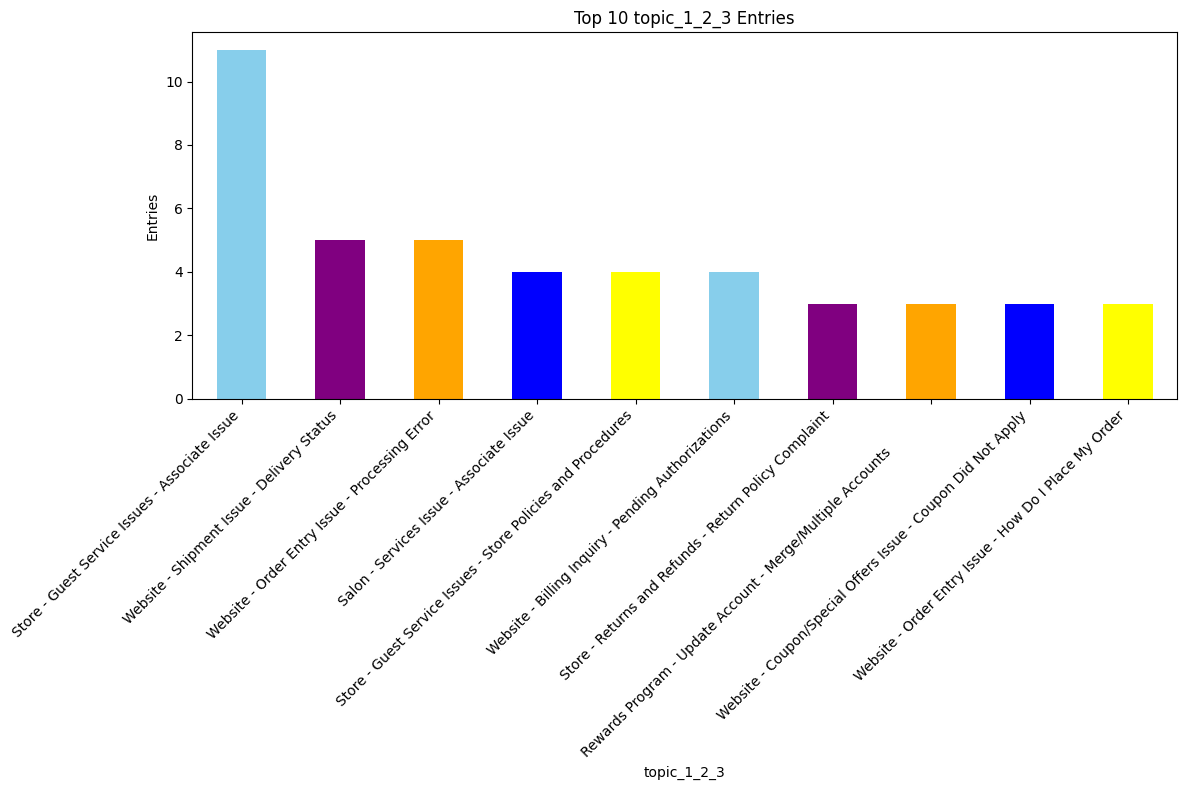

In [48]:

plt.figure(figsize=(12, 8))

# Get top 10 topics
top_topics = audit_df['topic_1_2_3'].value_counts().head(10)

# Plot
top_topics.plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("Top 10 topic_1_2_3 Entries")
plt.ylabel("Entries")
plt.xlabel("topic_1_2_3")
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

In [49]:

audit_df['opportunities'].unique().tolist()

['Empathy',
 'Resource Utilization',
 'Effective Communication',
 'Professionalism',
 'Resolution',
 'Efficiency',
 'Compliance (verification, sensitive issue escalations, legal, etc)',
 'Knowledge']

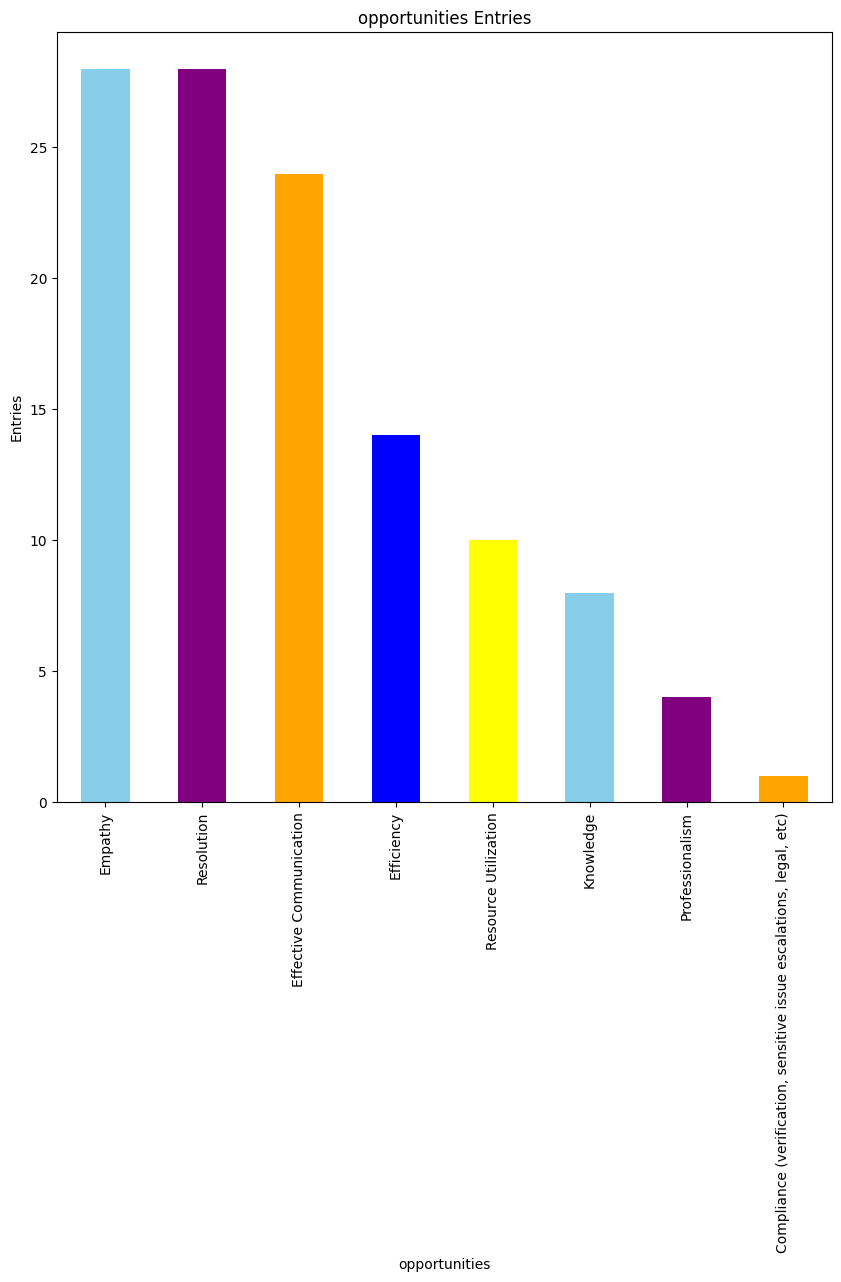

In [50]:
plt.figure(figsize=(10,10))
grafs = audit_df['opportunities'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("opportunities Entries")
plt.ylabel("Entries")
plt.xlabel("opportunities")
plt.tick_params(axis='x', labelsize=10)

In [51]:

audit_df['further_support'].unique().tolist()

['Empathy',
 'Customer Satisfaction',
 'De-Escalation',
 'KB Articles - How to locate',
 'System Navigation (LPS, IMB, GXP, Etc)',
 'Call Efficiencies (handle time, hold times and After call work)',
 'Quality',
 'Soft Skills']

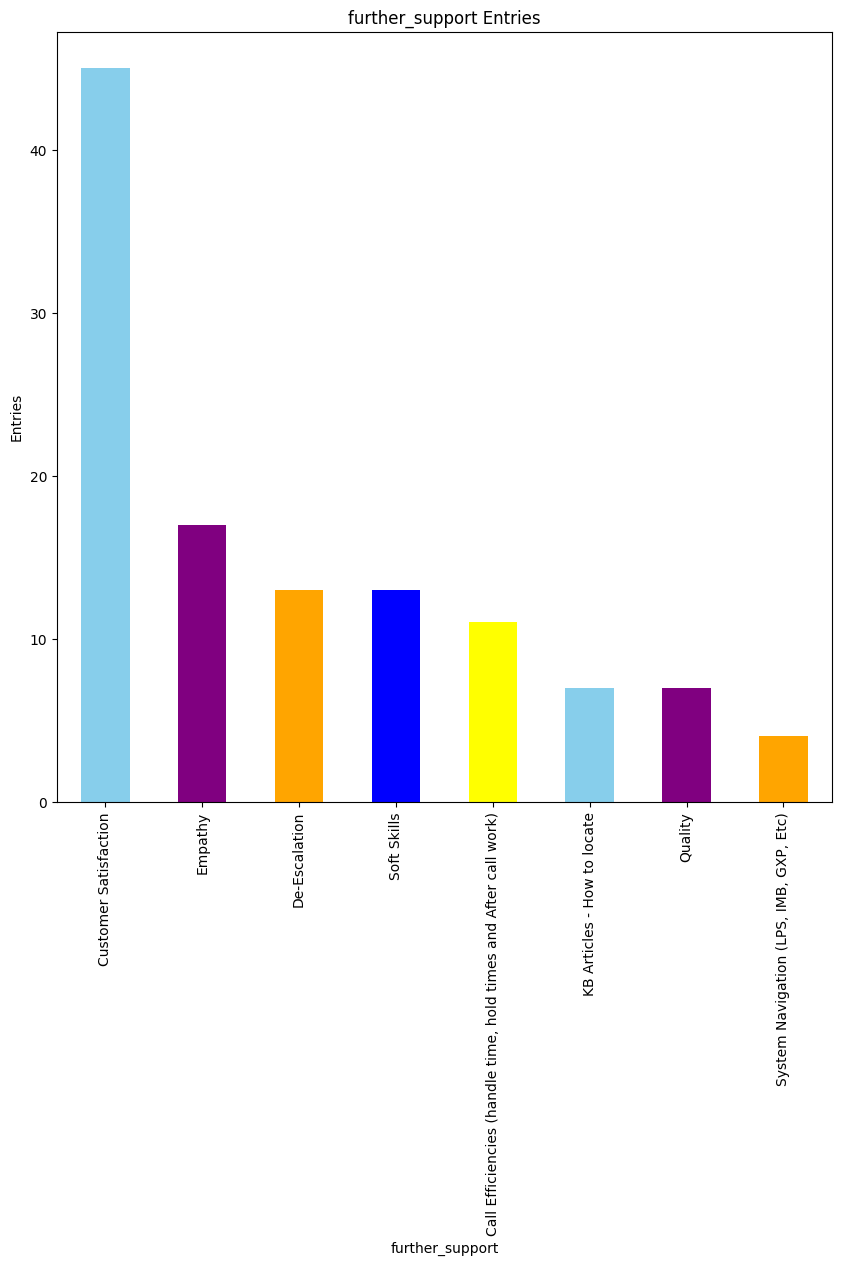

In [52]:
plt.figure(figsize=(10,10))
grafs = audit_df['further_support'].value_counts().plot(kind='bar', color=['skyblue', 'purple', 'orange', 'blue', 'yellow' ])

plt.title("further_support Entries")
plt.ylabel("Entries")
plt.xlabel("further_support")
plt.tick_params(axis='x', labelsize=10)

# **Correlation between data sets**

A direct correlation between full datasets isn’t possible — there’s a mismatch in granularity.

In [54]:
csat_df.head()


,week,response_date,contact_method,csat_count,sat_time,professionalism,knowledge,clarity,understand_needs,ability_solve,empathy,inquiry_resolved,inquiry_contact_count,topic_1_2_3,Tenure_Bucket,agent_name
0,2024-07-28,2024-07-31,Email,0,1,0,0,0,0,0,0,No,2-3 Times,Salon | Services Issue | Hair Service,Days 180+,agent_2
1,2024-04-07,2024-04-10,Email,0,0,0,0,0,0,0,0,No,2-3 Times,Store | Guest Service Issues | Associate Issue,Days 180+,agent_2
2,2024-04-28,2024-04-28,Email,0,0,0,0,0,0,0,0,No,First Contact,Store | Guest Service Issues | Associate Issue,Days 180+,agent_2
3,2024-06-09,2024-06-09,Voice,0,0,0,0,0,0,0,1,No,2-3 Times,Store | Returns and Refunds | Return Policy Co...,Days 180+,agent_2
4,2024-05-05,2024-05-05,Email,0,0,0,0,0,0,0,0,No,First Contact,Salon | Services Issue | Hair Service,Days 180+,agent_2


In [55]:
audit_df.head()

,date,agent_name,team_leader,home_channel,topic_1_2_3,professionalism,clarity,empathy,value_guest_time,ability_solve,opportunities,further_support,csat_count,self_csat
0,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1
1,2024-03-30,agent_2,Team_Leader_36,Store Team,Store - Guest Service Issues - Associate Issue,1,1,1,1,1,Resource Utilization,Customer Satisfaction,1,1
2,2024-03-29,agent_3,Team_Leader_37,Voice,Website - Shipment Issue - Delivery Status,1,0,0,0,1,Effective Communication,Customer Satisfaction,0,1
3,2024-03-28,agent_4,Team_Leader_37,Voice,Website - Shipment Issue - Stuck in Status,1,1,1,1,0,Professionalism,De-Escalation,0,0
4,2024-04-05,agent_5,Team_Leader_36,Store Team,Salon - Services Issue - Facilities Issue,1,1,1,1,1,Effective Communication,Customer Satisfaction,1,1


In [56]:
# Clean and standardize agent_name
audit_df['agent_name'] = audit_df['agent_name'].str.strip().str.lower()
csat_df['agent_name'] = csat_df['agent_name'].str.strip().str.lower()

# Create 'topic_1_2_3_clean' in both datasets
def clean_topic(topic):
    return topic.lower().strip().replace('|', '-').replace('--', '-').replace('  ', ' ')

audit_df['topic_1_2_3_clean'] = audit_df['topic_1_2_3'].astype(str).apply(clean_topic)
csat_df['topic_1_2_3_clean'] = csat_df['topic_1_2_3'].astype(str).apply(clean_topic)

# Merge on both agent_name and topic
columns_to_join = ["agent_name", "topic_1_2_3_clean"]
merged_by_agent = pd.merge(audit_df, csat_df, on=columns_to_join, suffixes=('_audit', '_csat'))

# Show preview
print(merged_by_agent.head())


         date agent_name     team_leader home_channel  \
0  2024-03-30    agent_1  Team_Leader_36        Voice   
1  2024-03-30    agent_1  Team_Leader_36        Voice   
2  2024-03-30    agent_1  Team_Leader_36        Voice   
3  2024-03-30    agent_1  Team_Leader_36        Voice   
4  2024-03-30    agent_1  Team_Leader_36        Voice   

                            topic_1_2_3_audit  professionalism_audit  \
0  Website - Shipment Issue - Delivery Status                      1   
1  Website - Shipment Issue - Delivery Status                      1   
2  Website - Shipment Issue - Delivery Status                      1   
3  Website - Shipment Issue - Delivery Status                      1   
4  Website - Shipment Issue - Delivery Status                      1   

   clarity_audit  empathy_audit  value_guest_time  ability_solve_audit  \
0              1              0                 1                    1   
1              1              0                 1                    1   
2 

In [53]:
# Standardize 'agent_name' to lowercase and strip spaces to ensure proper merging
audit_df['agent_name'] = audit_df['agent_name'].str.strip().str.lower()
csat_df['agent_name'] = csat_df['agent_name'].str.strip().str.lower()

columns_to_join = ["agent_name", "topic_1_2_3_clean"]

# Merge both datasets on 'agent_name'
merged_by_agent = pd.merge(audit_df, csat_df, on=columns_to_join, suffixes=('_audit', '_csat'))

# Optional: Display the first few rows to verify the result
print(merged_by_agent.head())

KeyError: 'topic_1_2_3_clean'

In [57]:
merged_by_agent.to_csv("merged_agent_data.csv", index=False)


In [58]:
merged_by_agent.head()

,date,agent_name,team_leader,home_channel,topic_1_2_3_audit,professionalism_audit,clarity_audit,empathy_audit,value_guest_time,ability_solve_audit,opportunities,further_support,csat_count_audit,self_csat,topic_1_2_3_clean,week,response_date,contact_method,csat_count_csat,sat_time,professionalism_csat,knowledge,clarity_csat,understand_needs,ability_solve_csat,empathy_csat,inquiry_resolved,inquiry_contact_count,topic_1_2_3_csat,Tenure_Bucket
0,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-06-02,2024-06-07,Voice,0,0,0,0,0,0,0,0,No,First Contact,Website | Shipment Issue | Delivery Status,Days 180+
1,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-07-14,2024-07-16,Voice,1,1,0,0,1,0,0,1,Yes,2-3 Times,Website | Shipment Issue | Delivery Status,Days 180+
2,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-03-03,2024-03-08,Voice,1,1,0,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,91-180 Days
3,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-02-11,2024-02-16,Voice,1,1,0,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,91-180 Days
4,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-06-23,2024-06-25,Voice,1,1,0,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,Days 180+


In [59]:
merged_by_agent.shape


(670, 30)

In [60]:
merged_by_agent.drop(["knowledge"], axis=1, inplace=True)

In [61]:
merged_by_agent[merged_by_agent.agent_name == 'agent_1']

,date,agent_name,team_leader,home_channel,topic_1_2_3_audit,professionalism_audit,clarity_audit,empathy_audit,value_guest_time,ability_solve_audit,opportunities,further_support,csat_count_audit,self_csat,topic_1_2_3_clean,week,response_date,contact_method,csat_count_csat,sat_time,professionalism_csat,clarity_csat,understand_needs,ability_solve_csat,empathy_csat,inquiry_resolved,inquiry_contact_count,topic_1_2_3_csat,Tenure_Bucket
0,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-06-02,2024-06-07,Voice,0,0,0,0,0,0,0,No,First Contact,Website | Shipment Issue | Delivery Status,Days 180+
1,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-07-14,2024-07-16,Voice,1,1,0,1,0,0,1,Yes,2-3 Times,Website | Shipment Issue | Delivery Status,Days 180+
2,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-03-03,2024-03-08,Voice,1,1,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,91-180 Days
3,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-02-11,2024-02-16,Voice,1,1,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,91-180 Days
4,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-06-23,2024-06-25,Voice,1,1,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,Days 180+
5,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-07-14,2024-07-15,Voice,1,1,0,1,0,1,1,No,First Contact,Website | Shipment Issue | Delivery Status,Days 180+
6,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-07-28,2024-07-31,Chat,1,1,0,1,0,1,1,Yes,4 or more times,Website | Shipment Issue | Delivery Status,Days 180+
7,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-03-24,2024-03-30,Voice,1,1,0,1,0,1,1,Yes,First Contact,Website | Shipment Issue | Delivery Status,91-180 Days
8,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-05-05,2024-05-09,Voice,1,1,0,1,0,1,1,Yes,2-3 Times,Website | Shipment Issue | Delivery Status,Days 180+
268,2024-05-09,agent_1,Team_Leader_36,Voice,Website - Coupon/Special Offers Issue - Coupon...,1,1,1,1,1,Efficiency,"Call Efficiencies (handle time, hold times and...",0,1,website - coupon/special offers issue - coupon...,2024-05-05,2024-05-09,Voice,0,0,0,0,0,0,0,Yes,2-3 Times,Website | Coupon/Special Offers Issue | Coupon...,Days 180+


In [62]:
merged_by_agent.drop_duplicates(subset=['agent_name', 'topic_1_2_3_clean'])

,date,agent_name,team_leader,home_channel,topic_1_2_3_audit,professionalism_audit,clarity_audit,empathy_audit,value_guest_time,ability_solve_audit,opportunities,further_support,csat_count_audit,self_csat,topic_1_2_3_clean,week,response_date,contact_method,csat_count_csat,sat_time,professionalism_csat,clarity_csat,understand_needs,ability_solve_csat,empathy_csat,inquiry_resolved,inquiry_contact_count,topic_1_2_3_csat,Tenure_Bucket
0,2024-03-30,agent_1,Team_Leader_36,Voice,Website - Shipment Issue - Delivery Status,1,1,0,1,1,Empathy,Empathy,1,1,website - shipment issue - delivery status,2024-06-02,2024-06-07,Voice,0,0,0,0,0,0,0,No,First Contact,Website | Shipment Issue | Delivery Status,Days 180+
9,2024-03-30,agent_2,Team_Leader_36,Store Team,Store - Guest Service Issues - Associate Issue,1,1,1,1,1,Resource Utilization,Customer Satisfaction,1,1,store - guest service issues - associate issue,2024-04-07,2024-04-10,Email,0,0,0,0,0,0,0,No,2-3 Times,Store | Guest Service Issues | Associate Issue,Days 180+
54,2024-03-29,agent_3,Team_Leader_37,Voice,Website - Shipment Issue - Delivery Status,1,0,0,0,1,Effective Communication,Customer Satisfaction,0,1,website - shipment issue - delivery status,2024-05-26,2024-05-30,Chat,0,0,0,0,0,0,1,Yes,4 or more times,Website | Shipment Issue | Delivery Status,Days 180+
63,2024-04-05,agent_5,Team_Leader_36,Store Team,Salon - Services Issue - Facilities Issue,1,1,1,1,1,Effective Communication,Customer Satisfaction,1,1,salon - services issue - facilities issue,2024-03-31,2024-04-05,Voice,0,1,0,1,0,1,1,No,First Contact,Salon | Services Issue | Facilities Issue,Days 180+
64,2024-04-03,agent_7,Team_Leader_38,Voice,Rewards Program - Program Questions - Birthday...,1,1,1,1,0,Resolution,Customer Satisfaction,1,1,rewards program - program questions - birthday...,2024-03-31,2024-04-03,Voice,0,1,0,1,0,1,1,Yes,First Contact,Rewards Program | Program Questions | Birthday...,Production 1-30 Days
73,2024-04-03,agent_2,Team_Leader_36,Store Team,Store - Guest Service Issues - Store Policies ...,1,1,1,1,1,Resource Utilization,Customer Satisfaction,1,1,store - guest service issues - store policies ...,2024-03-03,2024-03-07,Email,0,0,0,0,0,0,0,No,First Contact,Store | Guest Service Issues | Store Policies ...,Days 180+
77,2024-04-04,agent_5,Team_Leader_36,Email,Salon - Services Issue - Associate Issue,1,1,1,1,1,Effective Communication,Customer Satisfaction,0,1,salon - services issue - associate issue,2024-07-21,2024-07-26,Voice,1,0,0,1,0,1,1,Yes,4 or more times,Salon | Services Issue | Associate Issue,Days 180+
78,2024-04-04,agent_9,Team_Leader_37,Voice,Website - Buy Online Pickup in Store - Order C...,1,1,1,1,1,Effective Communication,Customer Satisfaction,1,0,website - buy online pickup in store - order c...,2024-04-21,2024-04-26,Voice,1,1,0,1,0,1,1,Yes,First Contact,Website | Buy Online Pickup in Store | Order C...,Days 180+
79,2024-04-04,agent_10,Team_Leader_36,Voice,Rewards Program - Points Issue - Missing Trans...,1,1,1,1,1,Resolution,Customer Satisfaction,0,1,rewards program - points issue - missing trans...,2024-03-31,2024-04-04,Voice,0,0,0,0,0,0,0,No,4 or more times,Rewards Program | Points Issue | Missing Trans...,Days 180+
82,2024-04-02,agent_11,Team_Leader_36,Email,Store - Guest Service Issues - Associate Issue,1,1,1,1,1,Resolution,Customer Satisfaction,0,1,store - guest service issues - associate issue,2024-03-31,2024-04-03,Voice,0,0,0,0,0,0,1,Yes,4 or more times,Store | Guest Service Issues | Associate Issue,91-180 Days


In [63]:
merged_by_agent['week'].unique().tolist()

['2024-06-02',
 '2024-07-14',
 '2024-03-03',
 '2024-02-11',
 '2024-06-23',
 '2024-07-28',
 '2024-03-24',
 '2024-05-05',
 '2024-04-07',
 '2024-04-28',
 '2024-08-04',
 '2024-03-31',
 '2024-07-07',
 '2024-03-17',
 '2024-03-10',
 '2024-02-04',
 '2024-05-19',
 '2024-02-25',
 '2024-04-14',
 '2024-04-21',
 '2024-09-08',
 '2024-06-16',
 '2024-06-30',
 '2024-08-18',
 '2024-05-26',
 '2024-08-11',
 '2024-01-21',
 '2024-07-21',
 '2024-09-15',
 '2024-02-18',
 '2024-09-01',
 '2024-06-09',
 '2024-08-25',
 '2024-05-12',
 '2024-01-07',
 '2024-01-28',
 '2024-01-14']

In [64]:
merged_by_agent['date'].unique().tolist()

['2024-03-30',
 '2024-03-29',
 '2024-04-05',
 '2024-04-03',
 '2024-04-04',
 '2024-04-02',
 '2024-04-08',
 '2024-04-10',
 '2024-04-09',
 '2024-04-11',
 '2024-03-08',
 '2024-04-07',
 '2024-04-19',
 '2024-04-15',
 '2024-04-25',
 '2024-04-27',
 '2024-04-24',
 '2024-04-26',
 '2024-04-23',
 '2024-04-29',
 '2024-05-01',
 '2024-05-03',
 '2024-04-30',
 '2024-05-04',
 '2024-05-12',
 '2024-05-06',
 '2024-05-09',
 '2024-05-11',
 '2024-05-13',
 '2024-05-16',
 '2024-05-17',
 '2024-05-18',
 '2024-05-23',
 '2024-05-29',
 '2024-05-20',
 '2024-05-26',
 '2024-05-31',
 '2024-05-30',
 '2024-06-07',
 '2024-06-15',
 '2024-06-14',
 '2024-06-13',
 '2024-06-10',
 '2024-06-16',
 '2024-06-21',
 '2024-06-19',
 '2024-06-24',
 '2024-06-27',
 '2024-06-29',
 '2024-07-05',
 '2024-07-02',
 '2024-07-10',
 '2024-07-08',
 '2024-07-09',
 '2024-07-15',
 '2024-07-14',
 '2024-07-18',
 '2024-07-19',
 '2024-07-27',
 '2024-08-17',
 '2024-08-27',
 '2024-08-30',
 '2024-09-06',
 '2024-09-02',
 '2024-09-01']

In [67]:
# Show side-by-side comparison of 'date' from audit and 'week' from CSAT
date_week_comparison = merged_by_agent[['date', 'week']]

# Display the first few rows
print(date_week_comparison.head(10))


         date        week
0  2024-03-30  2024-06-02
1  2024-03-30  2024-07-14
2  2024-03-30  2024-03-03
3  2024-03-30  2024-02-11
4  2024-03-30  2024-06-23
5  2024-03-30  2024-07-14
6  2024-03-30  2024-07-28
7  2024-03-30  2024-03-24
8  2024-03-30  2024-05-05
9  2024-03-30  2024-04-07


In [68]:
# Show side-by-side comparison of 'date' from audit and 'week' from CSAT
date_week_comparison = merged_by_agent[['date', 'week']]

# Display the first few rows
print(date_week_comparison.head(10))

         date        week
0  2024-03-30  2024-06-02
1  2024-03-30  2024-07-14
2  2024-03-30  2024-03-03
3  2024-03-30  2024-02-11
4  2024-03-30  2024-06-23
5  2024-03-30  2024-07-14
6  2024-03-30  2024-07-28
7  2024-03-30  2024-03-24
8  2024-03-30  2024-05-05
9  2024-03-30  2024-04-07


In [69]:
# Convert to datetime (if not already)
merged_by_agent['date'] = pd.to_datetime(merged_by_agent['date'])
merged_by_agent['week'] = pd.to_datetime(merged_by_agent['week'])

# Calculate difference in days
merged_by_agent['date_week_diff'] = (merged_by_agent['date'] - merged_by_agent['week']).dt.days

# Show relevant columns
# Display all rows of 'date' and 'week' columns
pd.set_option('display.max_rows', None)  # Ensure all rows are shown

# Show the columns side by side
print(merged_by_agent[['date', 'week']])


print(merged_by_agent[['agent_name', 'date', 'week', 'date_week_diff']].head())


          date       week
0   2024-03-30 2024-06-02
1   2024-03-30 2024-07-14
2   2024-03-30 2024-03-03
3   2024-03-30 2024-02-11
4   2024-03-30 2024-06-23
5   2024-03-30 2024-07-14
6   2024-03-30 2024-07-28
7   2024-03-30 2024-03-24
8   2024-03-30 2024-05-05
9   2024-03-30 2024-04-07
10  2024-03-30 2024-04-28
11  2024-03-30 2024-08-04
12  2024-03-30 2024-03-31
13  2024-03-30 2024-07-07
14  2024-03-30 2024-03-24
15  2024-03-30 2024-05-05
16  2024-03-30 2024-07-28
17  2024-03-30 2024-03-31
18  2024-03-30 2024-04-28
19  2024-03-30 2024-07-07
20  2024-03-30 2024-03-17
21  2024-03-30 2024-02-11
22  2024-03-30 2024-03-10
23  2024-03-30 2024-02-11
24  2024-03-30 2024-02-04
25  2024-03-30 2024-05-19
26  2024-03-30 2024-04-07
27  2024-03-30 2024-02-25
28  2024-03-30 2024-03-03
29  2024-03-30 2024-06-02
30  2024-03-30 2024-03-31
31  2024-03-30 2024-05-05
32  2024-03-30 2024-08-04
33  2024-03-30 2024-03-10
34  2024-03-30 2024-07-07
35  2024-03-30 2024-02-11
36  2024-03-30 2024-07-07
37  2024-03-

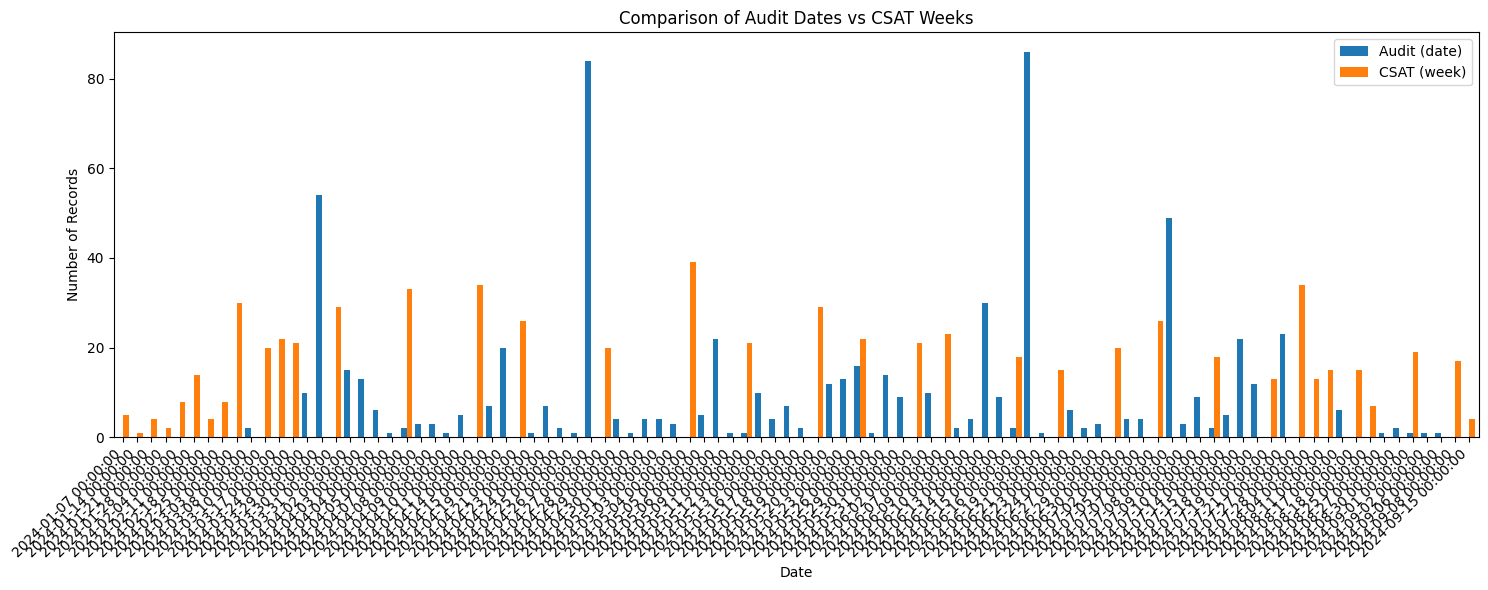

In [70]:
# Ensure 'date' and 'week' are in datetime format
merged_by_agent['date'] = pd.to_datetime(merged_by_agent['date'])
merged_by_agent['week'] = pd.to_datetime(merged_by_agent['week'])

# Count occurrences by date and week
date_counts = merged_by_agent['date'].value_counts().sort_index()
week_counts = merged_by_agent['week'].value_counts().sort_index()

# Align them in a new DataFrame
time_comparison = pd.DataFrame({
    'audit_date': date_counts,
    'csat_week': week_counts
}).fillna(0)

# Plot
time_comparison.plot(kind='bar', figsize=(15, 6), width=0.8)
plt.title("Comparison of Audit Dates vs CSAT Weeks")
plt.xlabel("Date")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.legend(["Audit (date)", "CSAT (week)"])
plt.tight_layout()
plt.show()

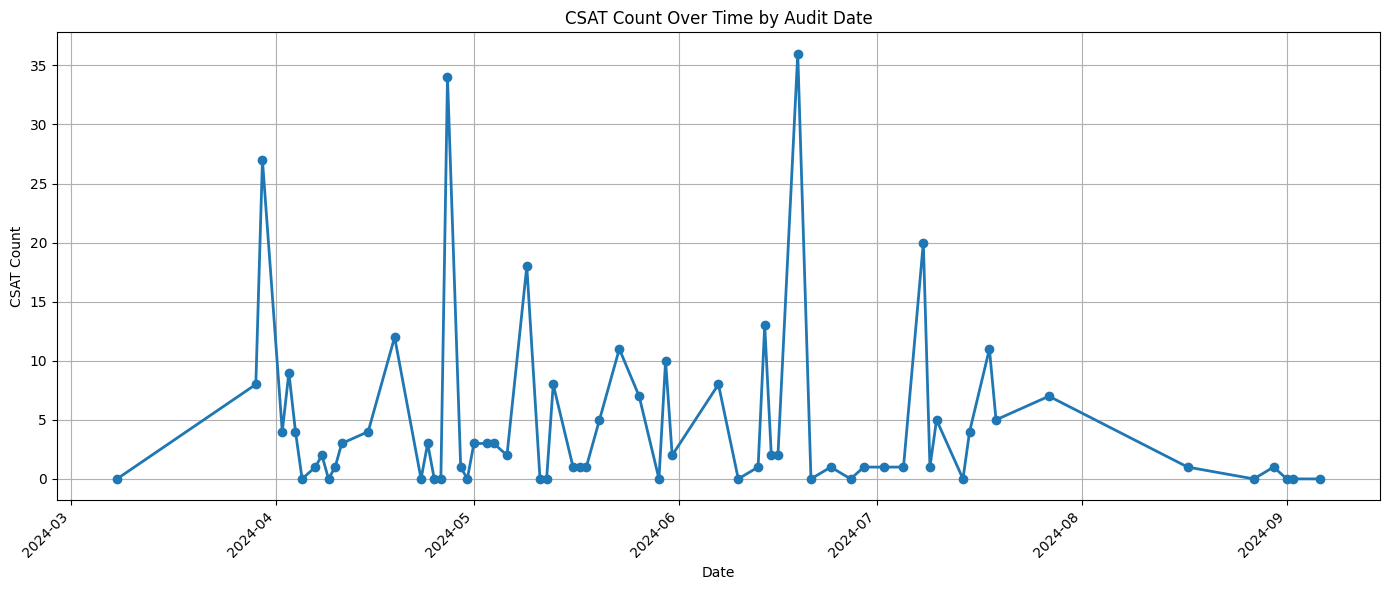

In [71]:
merged_by_agent['date'] = pd.to_datetime(merged_by_agent['date'])

# Group by date and sum csat_count
csat_by_date = merged_by_agent.groupby('date')['csat_count_csat'].sum()

# Plot the time series
plt.figure(figsize=(14, 6))
csat_by_date.plot(kind='line', marker='o', linewidth=2)

plt.title("CSAT Count Over Time by Audit Date")
plt.xlabel("Date")
plt.ylabel("CSAT Count")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

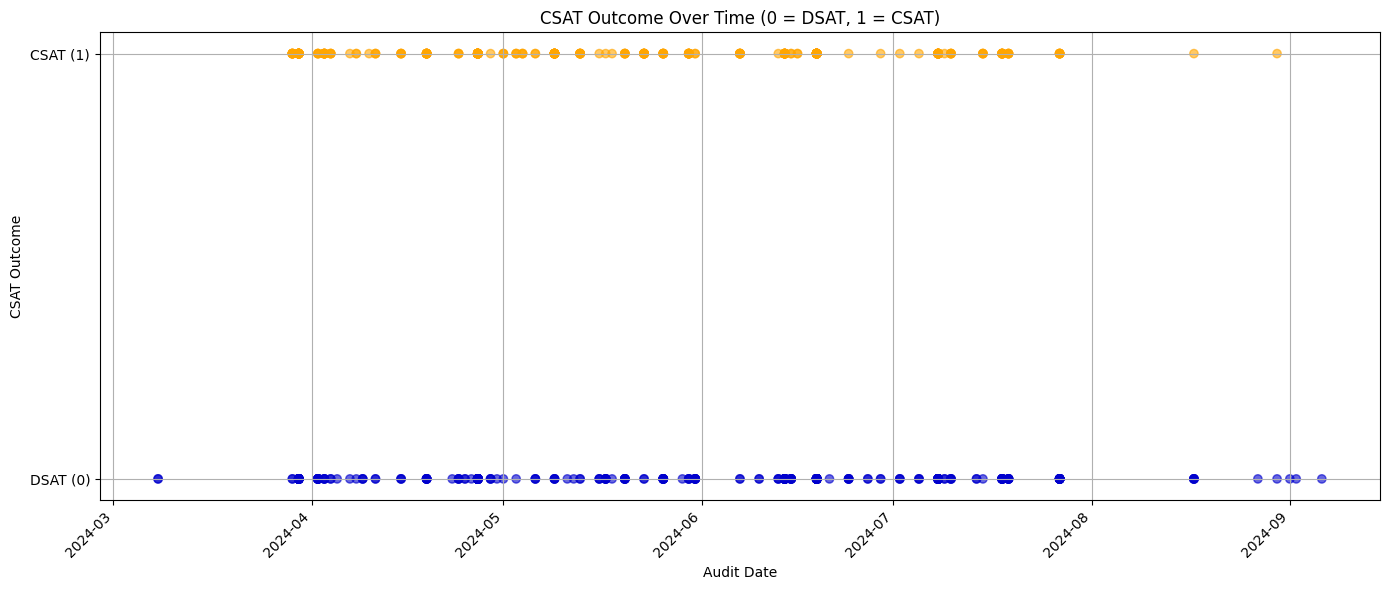

In [74]:
import matplotlib.pyplot as plt

# Ensure 'date' is datetime
merged_by_agent['date'] = pd.to_datetime(merged_by_agent['date'])

# Map CSAT values to colors
colors = merged_by_agent['csat_count_csat'].map({0: 'mediumblue', 1: 'orange'})

# Create the scatter plot
plt.figure(figsize=(14, 6))
plt.scatter(
    merged_by_agent['date'],
    merged_by_agent['csat_count_csat'],
    alpha=0.6,
    c=colors
)

plt.title("CSAT Outcome Over Time (0 = DSAT, 1 = CSAT)")
plt.xlabel("Audit Date")
plt.ylabel("CSAT Outcome")
plt.yticks([0, 1], ['DSAT (0)', 'CSAT (1)'])
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


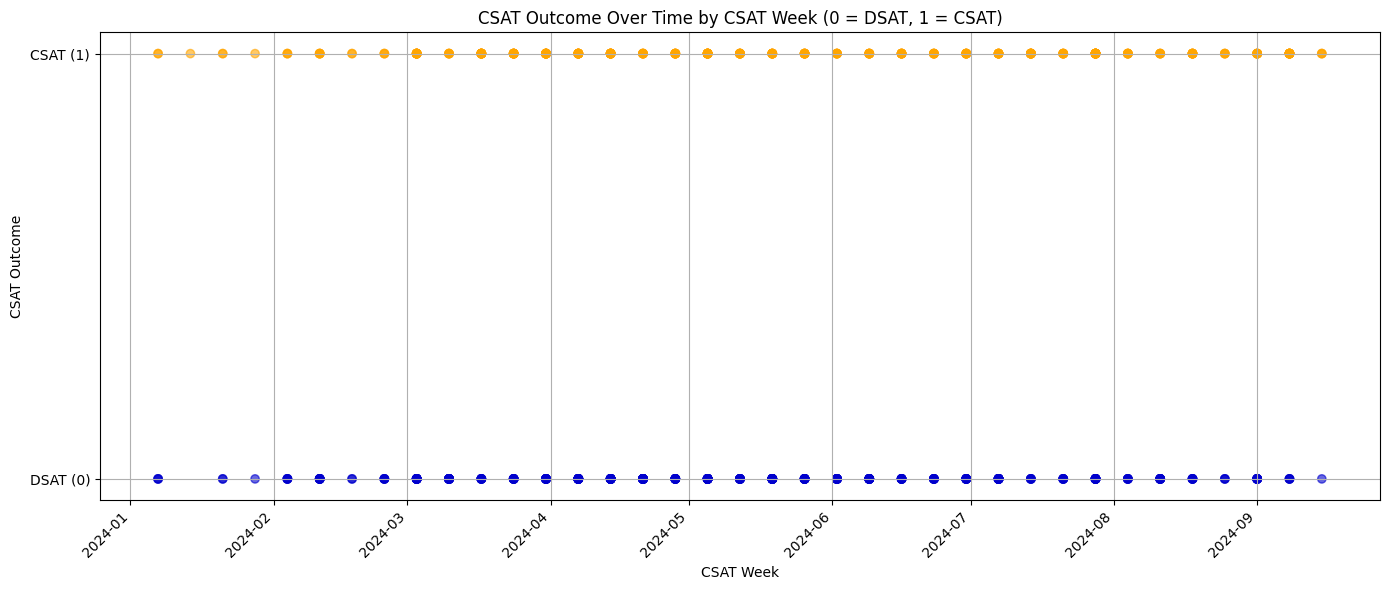

In [75]:
import matplotlib.pyplot as plt

# Ensure 'week' is in datetime format
merged_by_agent['week'] = pd.to_datetime(merged_by_agent['week'])

# Map CSAT values to colors
colors = merged_by_agent['csat_count_csat'].map({0: 'mediumblue', 1: 'orange'})

# Create scatter plot: CSAT over time by CSAT Week
plt.figure(figsize=(14, 6))
plt.scatter(
    merged_by_agent['week'],
    merged_by_agent['csat_count_csat'],
    alpha=0.6,
    c=colors
)

plt.title("CSAT Outcome Over Time by CSAT Week (0 = DSAT, 1 = CSAT)")
plt.xlabel("CSAT Week")
plt.ylabel("CSAT Outcome")
plt.yticks([0, 1], ['DSAT (0)', 'CSAT (1)'])
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


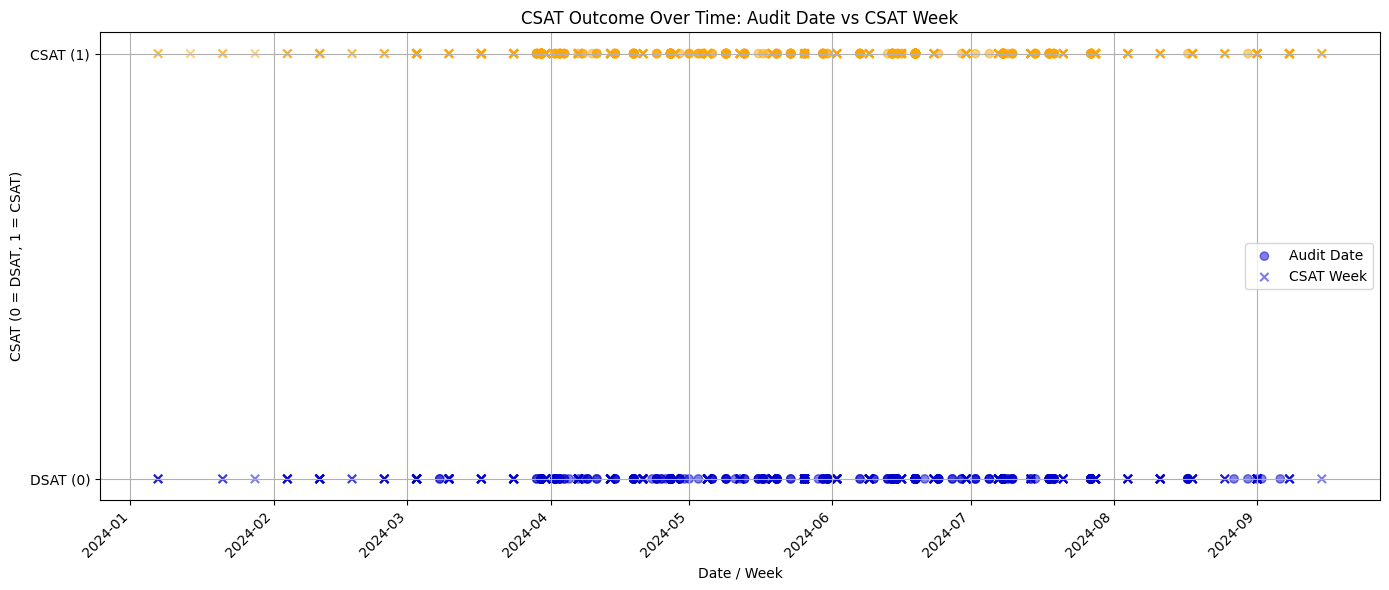

In [77]:
# Ensure both date and week are datetime format
merged_by_agent['date'] = pd.to_datetime(merged_by_agent['date'])
merged_by_agent['week'] = pd.to_datetime(merged_by_agent['week'])

# Map CSAT values to colors
colors = merged_by_agent['csat_count_csat'].map({0: 'mediumblue', 1: 'orange'})

# Create the dual scatter plot
plt.figure(figsize=(14, 6))

# Plot by audit date
plt.scatter(
    merged_by_agent['date'],
    merged_by_agent['csat_count_csat'],
    alpha=0.5,
    c=colors,
    label='Audit Date',
    marker='o'
)

# Plot by CSAT week
plt.scatter(
    merged_by_agent['week'],
    merged_by_agent['csat_count_csat'],
    alpha=0.5,
    c=colors,
    label='CSAT Week',
    marker='x'
)

plt.title("CSAT Outcome Over Time: Audit Date vs CSAT Week")
plt.xlabel("Date / Week")
plt.ylabel("CSAT (0 = DSAT, 1 = CSAT)")
plt.yticks([0, 1], ['DSAT (0)', 'CSAT (1)'])
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

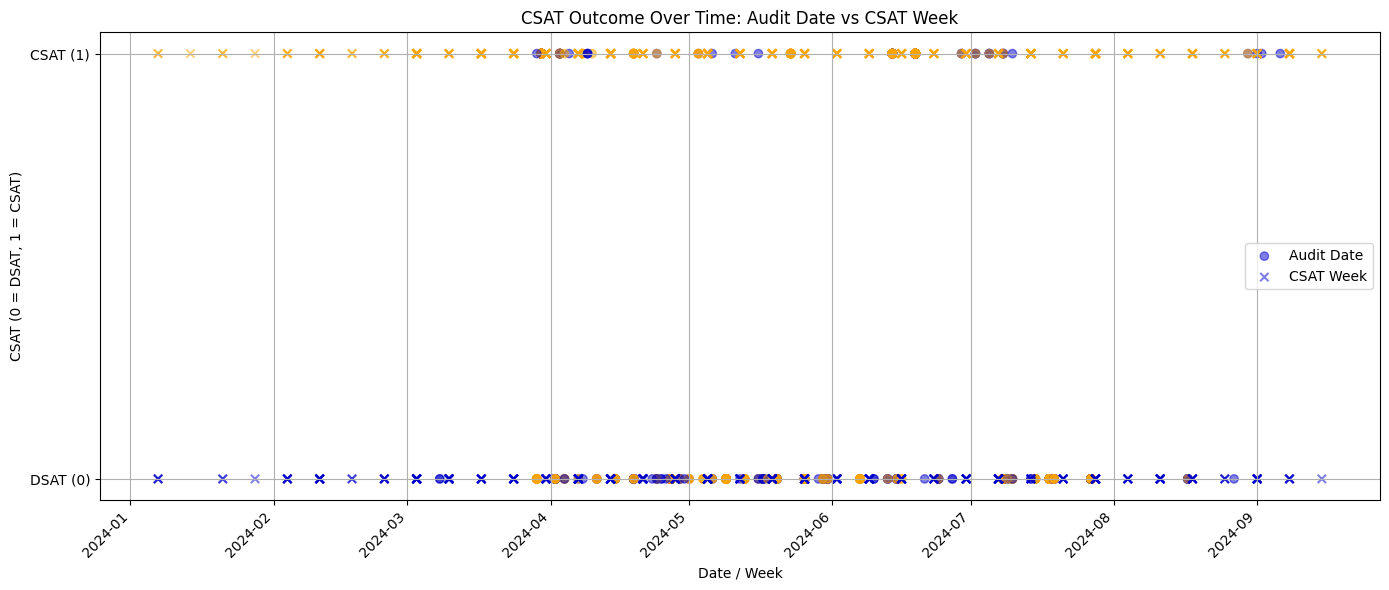

In [78]:
# Ensure both date and week are datetime format
merged_by_agent['date'] = pd.to_datetime(merged_by_agent['date'])
merged_by_agent['week'] = pd.to_datetime(merged_by_agent['week'])

# Map CSAT values to colors
colors = merged_by_agent['csat_count_csat'].map({0: 'mediumblue', 1: 'orange'})

# Create the dual scatter plot
plt.figure(figsize=(14, 6))

# Plot by audit date
plt.scatter(
    merged_by_agent['date'],
    merged_by_agent['csat_count_audit'],
    alpha=0.5,
    c=colors,
    label='Audit Date',
    marker='o'
)

# Plot by CSAT week
plt.scatter(
    merged_by_agent['week'],
    merged_by_agent['csat_count_csat'],
    alpha=0.5,
    c=colors,
    label='CSAT Week',
    marker='x'
)

plt.title("CSAT Outcome Over Time: Audit Date vs CSAT Week")
plt.xlabel("Date / Week")
plt.ylabel("CSAT (0 = DSAT, 1 = CSAT)")
plt.yticks([0, 1], ['DSAT (0)', 'CSAT (1)'])
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()